### import libs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import re

### data paths

In [2]:
root1=Path('raw_data')
root1.mkdir(exist_ok=True)

In [3]:
root2=Path('final_data')
root2.mkdir(exist_ok=True)

### merge csv

In [4]:
final_df = []

for file in root1.glob("*.csv"):

    filename = file.stem.lower()

    # Extract location
    match = re.search(r"raw_data_data_(.*?),_delhi", filename)

    if not match:
        print(f"Could not extract location: {file.name}")
        continue

    location = match.group(1)

    # Convert underscores to spaces
    location = location.replace("_", " ").strip()

    # Read CSV
    df = pd.read_csv(file)

    # Add location as the FIRST column
    df.insert(0, "location", location)

    final_df.append(df)


In [5]:
# Merge everything
final_df = pd.concat(final_df, ignore_index=True)

In [6]:
final_df

,location,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
0,alipur,2025-01-01 00:00:00,251.00,374.0,102.03,58.83,114.27,74.83,13.20,2.81,...,NaN,11.10,89.00,0.33,251.00,NaN,0.0,5.00,740.00,NaN
1,alipur,2025-01-01 01:00:00,269.00,437.0,102.10,61.60,115.80,74.32,12.35,2.74,...,NaN,10.85,89.75,0.35,251.00,NaN,0.0,5.00,740.00,NaN
2,alipur,2025-01-01 02:00:00,238.00,326.0,59.90,63.22,82.35,81.50,14.50,2.38,...,NaN,11.08,89.25,0.68,251.00,NaN,0.0,5.00,740.00,NaN
3,alipur,2025-01-01 03:00:00,227.00,324.0,44.08,61.25,68.40,70.03,16.45,2.00,...,NaN,11.40,86.50,1.05,251.00,NaN,0.0,5.00,740.00,NaN
4,alipur,2025-01-01 04:00:00,286.00,381.0,31.90,51.35,53.25,66.12,15.75,1.81,...,NaN,11.42,85.50,0.60,251.00,NaN,0.0,5.00,740.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2201035,wazirpur,2026-08-31 19:00:00,30.75,489.0,50.43,36.03,60.15,36.70,15.28,1.11,...,NaN,33.15,60.25,0.33,144.25,NaN,NaN,27.25,729.25,NaN
2201036,wazirpur,2026-08-31 20:00:00,35.75,497.0,64.95,31.25,69.45,31.25,21.60,1.44,...,NaN,32.58,62.50,0.33,142.50,NaN,NaN,26.50,729.00,NaN
2201037,wazirpur,2026-08-31 21:00:00,48.75,432.0,132.05,24.93,120.73,29.50,24.33,1.71,...,NaN,32.43,63.00,0.30,140.75,NaN,NaN,25.50,729.00,NaN
2201038,wazirpur,2026-08-31 22:00:00,76.25,406.0,82.35,24.83,80.18,28.08,23.35,1.76,...,NaN,32.43,65.75,0.30,142.75,NaN,NaN,25.25,728.75,NaN


In [7]:
# Save
output_file = root2 / "delhi_air_quality_merged.csv"
final_df.to_csv(output_file, index=False)

print(f"Total files merged: {len(final_df)}")
print(f"Total rows: {len(final_df)}")
print(f"Total columns: {len(final_df.columns)}")
print(f"Saved to: {output_file}")

Total files merged: 2201040
Total rows: 2201040
Total columns: 26
Saved to: final_data\delhi_air_quality_merged.csv


### details of data

In [8]:
print("Shape:", final_df.shape)

Shape: (2201040, 26)


In [9]:
print("Number of unique locations:", final_df["location"].nunique())

Number of unique locations: 44


In [10]:
print("Columns:",final_df.columns )

Columns: Index(['location', 'Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
       'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)',
       'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)',
       'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)',
       'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)',
       'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)'],
      dtype='object')


In [11]:
print("\nUnique locations:")
print(final_df["location"].unique())


Unique locations:
['alipur' 'anand vihar' 'ashok vihar' 'aya nagar' 'bawana'
 'burari crossing' 'chandni chowk' 'commonwealth sports complex'
 'crri mathura road' 'dr. karni singh shooting range' 'dtu'
 'dwarka-sector 8' 'igi airport (t3)' 'ignou maidan garhi'
 'ihbas, dilshad garden' 'iit delhi' 'imd lodhi road' 'ito' 'jahangirpuri'
 'jawaharlal nehru stadium' 'jnu' 'lodhi road'
 'major dhyan chand national stadium' 'mandir marg' 'mundka' 'najafgarh'
 'narela' 'nehru nagar' 'north campus, du' 'nsit dwarka' 'nsut jaffarpur'
 'okhla phase-2' 'patparganj' 'punjabi bagh' 'pusa' 'rohini' 'r k puram'
 'shadipur' 'sirifort' 'sonia vihar' 'sri aurobindo marg'
 'talkatora garden' 'vivek vihar' 'wazirpur']


In [12]:
print("\nRows per location:")
print(final_df.groupby("location").size().sort_values(ascending=False))


Rows per location:
location
pusa                                  97824
alipur                                48912
ashok vihar                           48912
anand vihar                           48912
bawana                                48912
burari crossing                       48912
chandni chowk                         48912
commonwealth sports complex           48912
crri mathura road                     48912
dr. karni singh shooting range        48912
dtu                                   48912
aya nagar                             48912
dwarka-sector 8                       48912
igi airport (t3)                      48912
ihbas, dilshad garden                 48912
ignou maidan garhi                    48912
imd lodhi road                        48912
ito                                   48912
jahangirpuri                          48912
iit delhi                             48912
jnu                                   48912
lodhi road                            48912
maj

In [13]:
null_summary = pd.DataFrame({
    "null_count": final_df.isnull().sum(),
    "null_percentage": (final_df.isnull().mean() * 100).round(2)
})

null_summary = null_summary.sort_values("null_count", ascending=False)

print(null_summary)

                     null_count  null_percentage
O Xylene (µg/m³)        2201040           100.00
Xylene (µg/m³)          2201040           100.00
RF (mm)                 2201040           100.00
Eth-Benzene (µg/m³)     2201040           100.00
MP-Xylene (µg/m³)       2007180            91.19
VWS (m/s)               2002410            90.98
Benzene (µg/m³)          421515            19.15
Toluene (µg/m³)          395100            17.95
CO (mg/m³)               334485            15.20
BP (mmHg)                277380            12.60
SO2 (µg/m³)              264960            12.04
NO (µg/m³)               248265            11.28
NH3 (µg/m³)              238590            10.84
NOx (ppb)                230040            10.45
TOT-RF (mm)              228960            10.40
NO2 (µg/m³)              210870             9.58
Ozone (µg/m³)            196380             8.92
PM10 (µg/m³)             196290             8.92
PM2.5 (µg/m³)            184095             8.36
WD (deg)            

In [14]:
final_df=final_df.drop(['O Xylene (µg/m³)','Xylene (µg/m³)','RF (mm)','Eth-Benzene (µg/m³)','MP-Xylene (µg/m³)','VWS (m/s)','TOT-RF (mm)'],axis=1)
final_df=final_df.dropna().reset_index(drop=True)

In [15]:
final_df['Timestamp']=final_df['Timestamp'].apply(lambda x: int(x.split('-')[1]))

In [16]:
final_df

,location,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Toluene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),SR (W/mt2),BP (mmHg)
0,alipur,1,251.00,374.0,102.03,58.83,114.27,74.83,13.20,2.81,1.93,6.23,46.30,11.10,89.00,0.33,251.00,5.00,740.00
1,alipur,1,269.00,437.0,102.10,61.60,115.80,74.32,12.35,2.74,3.05,6.25,45.60,10.85,89.75,0.35,251.00,5.00,740.00
2,alipur,1,238.00,326.0,59.90,63.22,82.35,81.50,14.50,2.38,4.08,5.72,42.88,11.08,89.25,0.68,251.00,5.00,740.00
3,alipur,1,227.00,324.0,44.08,61.25,68.40,70.03,16.45,2.00,2.50,6.00,38.80,11.40,86.50,1.05,251.00,5.00,740.00
4,alipur,1,286.00,381.0,31.90,51.35,53.25,66.12,15.75,1.81,2.55,5.72,36.35,11.42,85.50,0.60,251.00,5.00,740.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1228000,wazirpur,8,30.75,489.0,50.43,36.03,60.15,36.70,15.28,1.11,10.15,0.13,6.18,33.15,60.25,0.33,144.25,27.25,729.25
1228001,wazirpur,8,35.75,497.0,64.95,31.25,69.45,31.25,21.60,1.44,10.35,0.23,5.15,32.58,62.50,0.33,142.50,26.50,729.00
1228002,wazirpur,8,48.75,432.0,132.05,24.93,120.73,29.50,24.33,1.71,10.65,1.03,9.38,32.43,63.00,0.30,140.75,25.50,729.00
1228003,wazirpur,8,76.25,406.0,82.35,24.83,80.18,28.08,23.35,1.76,10.83,0.75,12.60,32.43,65.75,0.30,142.75,25.25,728.75


In [17]:
print("\nRows per time:")
print(final_df.groupby("Timestamp").size().sort_values(ascending=False))


Rows per time:
Timestamp
1     124560
2     123390
5     117225
8     116775
6     115560
4     113445
3     103050
7      95220
11     86580
12     84870
10     81360
9      65970
dtype: int64


In [18]:
print("Shape:", final_df.shape)

Shape: (1228005, 19)


In [19]:
final_df.dtypes

location            object
Timestamp            int64
PM2.5 (µg/m³)      float64
PM10 (µg/m³)       float64
NO (µg/m³)         float64
NO2 (µg/m³)        float64
NOx (ppb)          float64
NH3 (µg/m³)        float64
SO2 (µg/m³)        float64
CO (mg/m³)         float64
Ozone (µg/m³)      float64
Benzene (µg/m³)    float64
Toluene (µg/m³)    float64
AT (°C)            float64
RH (%)             float64
WS (m/s)           float64
WD (deg)           float64
SR (W/mt2)         float64
BP (mmHg)          float64
dtype: object

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
final_df["location"] = le.fit_transform(final_df["location"])

In [21]:
print("Total duplicate rows:", final_df.duplicated().sum())

print(
    "Duplicate percentage:",
    round(final_df.duplicated().mean() * 100, 2),
    "%"
)

Total duplicate rows: 27289
Duplicate percentage: 2.22 %


In [22]:
final_df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
location,1228005.0,21.777778,12.691015,0.00,11.00,22.00,33.00,43.000
Timestamp,1228005.0,6.020045,3.408146,1.00,3.00,6.00,9.00,12.000
PM2.5 (µg/m³),1228005.0,120.799600,102.205662,1.00,51.00,85.75,159.00,843.500
PM10 (µg/m³),1228005.0,284.994827,174.510548,6.00,155.50,252.00,376.00,998.000
NO (µg/m³),1228005.0,71.708903,92.524027,0.00,12.72,33.55,90.18,499.500
NO2 (µg/m³),1228005.0,69.620808,44.598170,0.00,38.80,61.38,90.38,498.900
NOx (ppb),1228005.0,95.711673,89.411906,0.00,35.00,65.00,122.52,499.500
NH3 (µg/m³),1228005.0,37.945118,20.437454,0.20,22.93,35.30,50.75,320.200
SO2 (µg/m³),1228005.0,20.411434,14.617272,0.00,11.28,17.90,26.00,197.150
CO (mg/m³),1228005.0,1.909544,1.204514,0.00,1.10,1.67,2.40,9.590


### inital Plots

In [23]:
correlation = final_df.select_dtypes(include=np.number).corr()

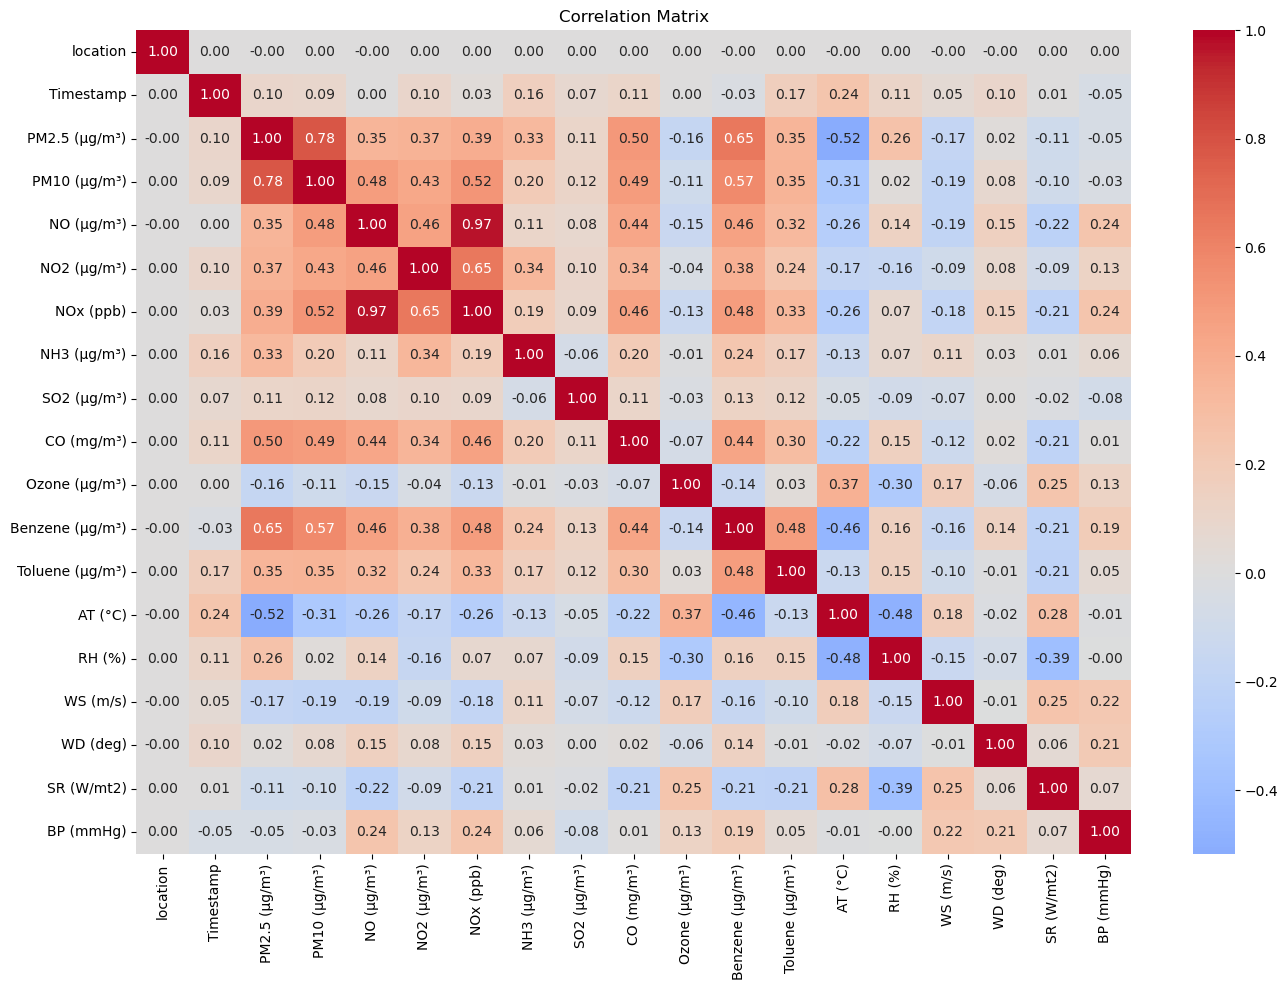

In [206]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("Correlation Matrix_light.png", dpi=1000)
plt.show()


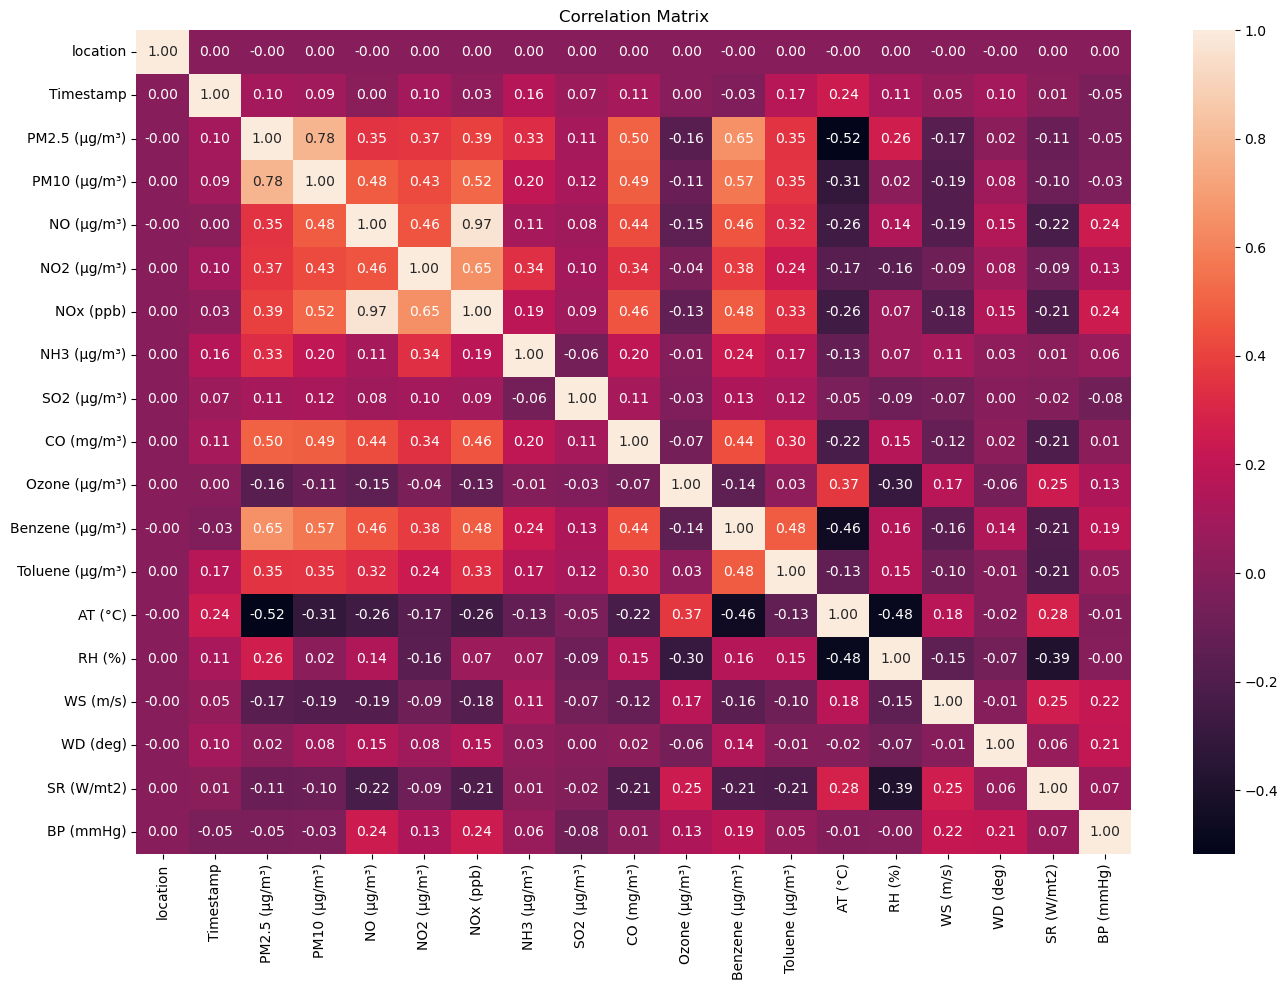

In [208]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation,annot=True,fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("Correlation Matrix_dark.png", dpi=1000)
plt.show()

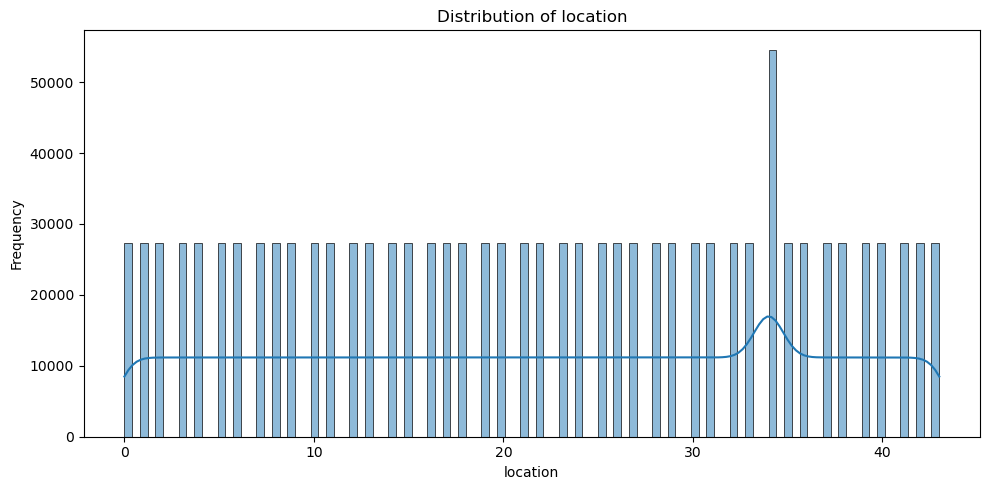

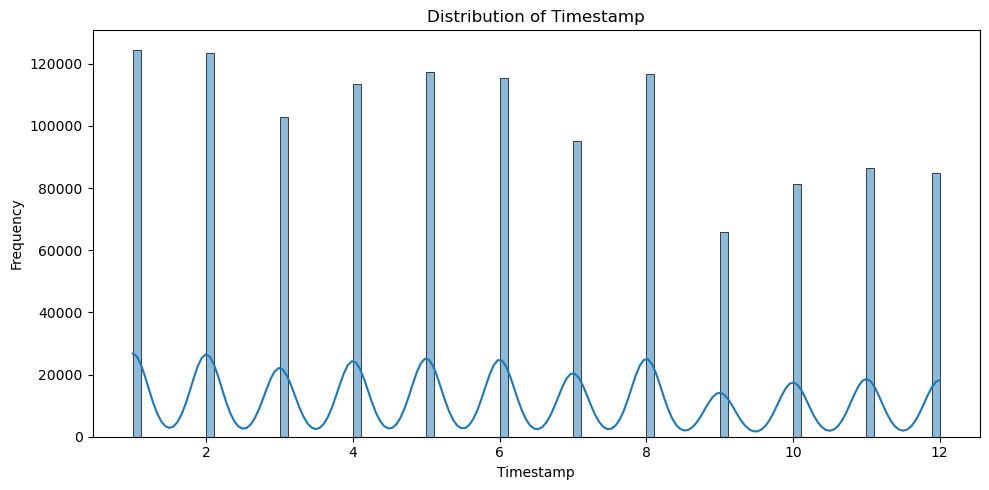

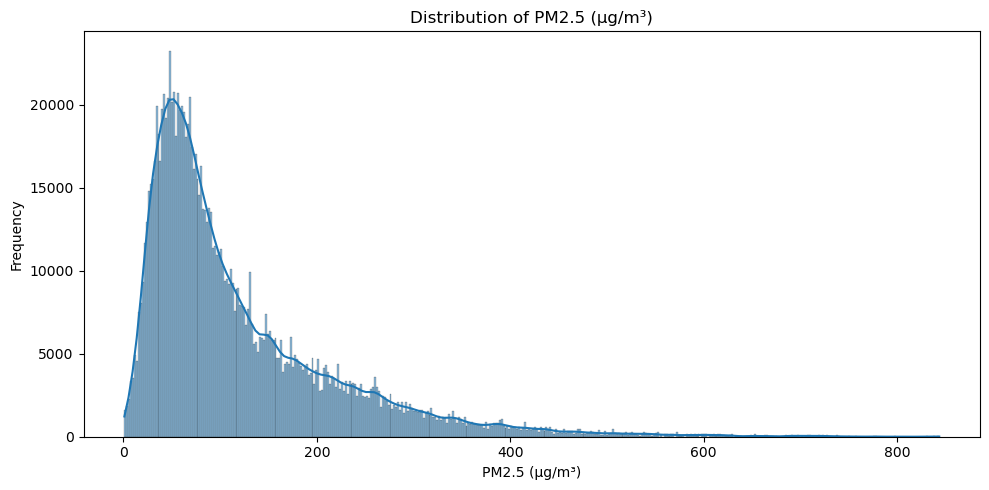

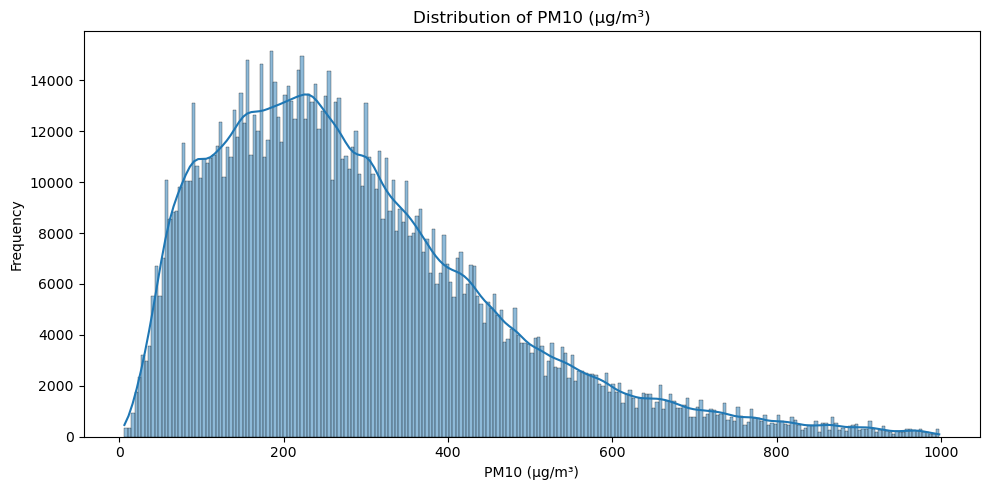

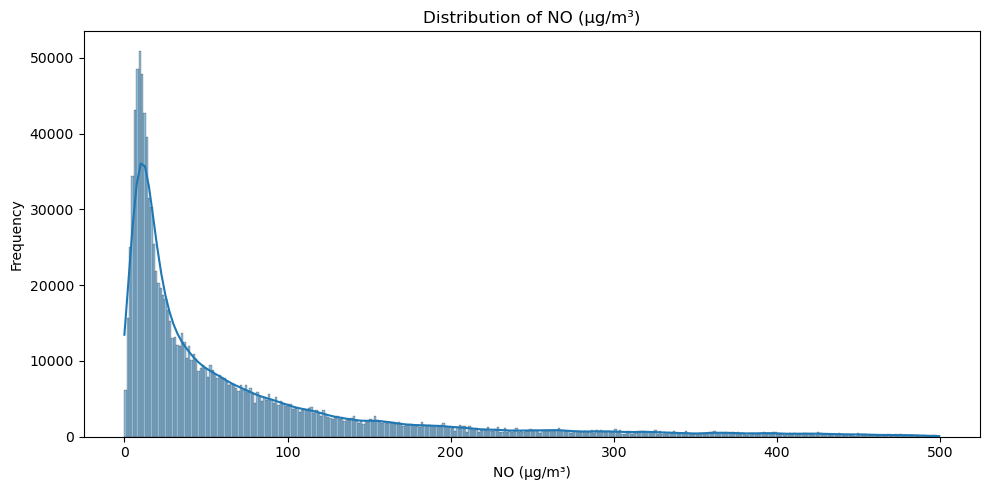

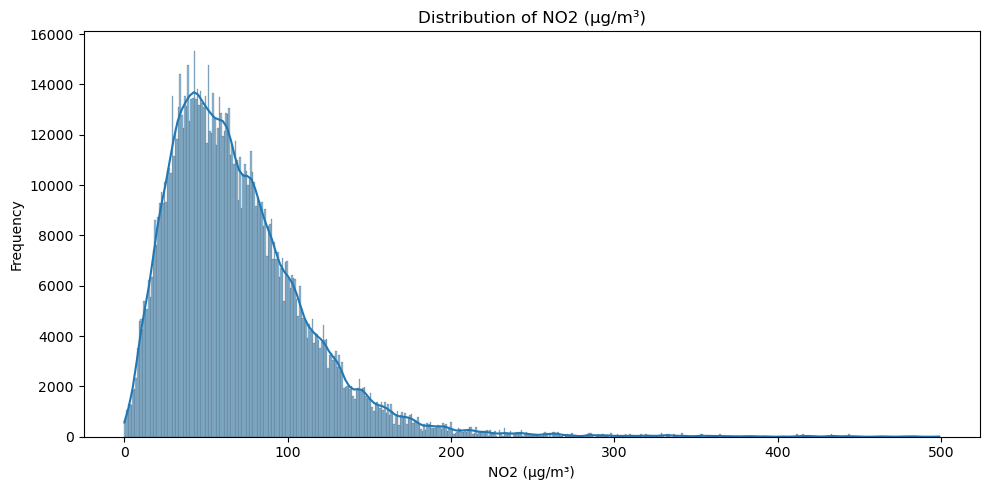

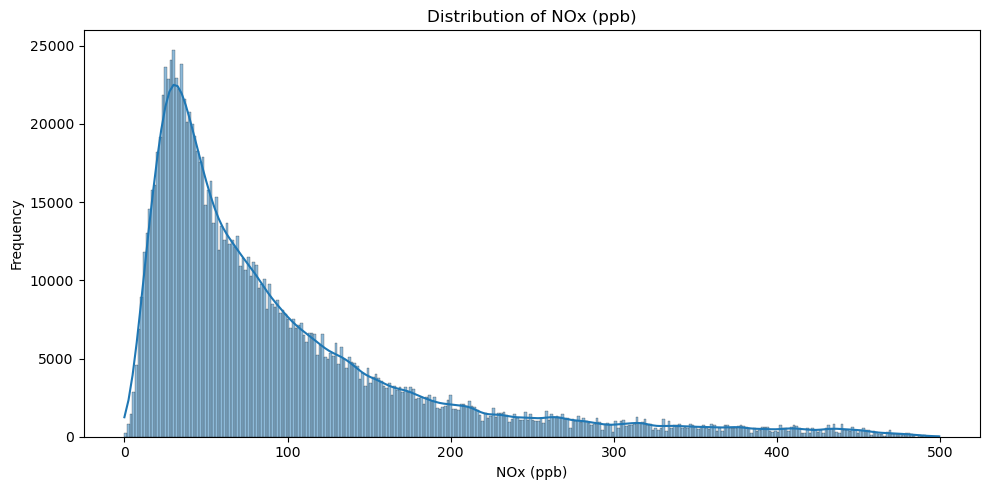

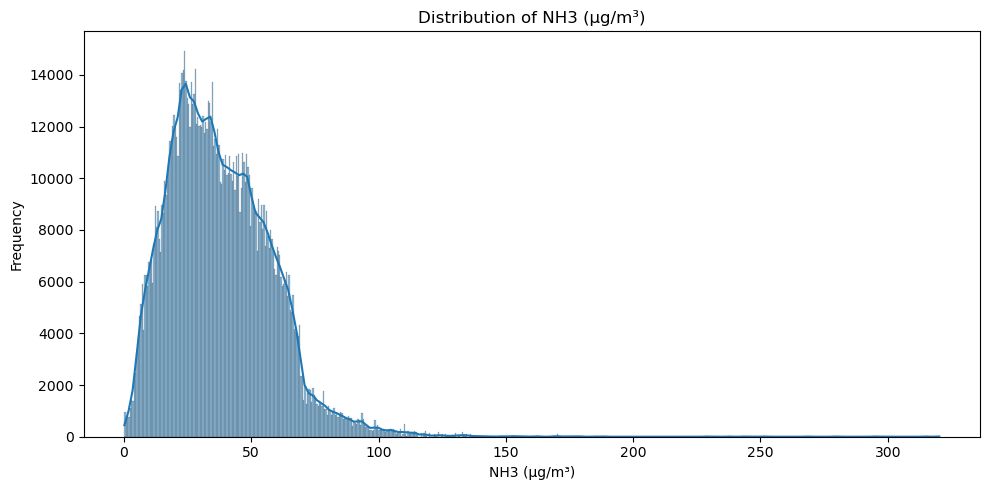

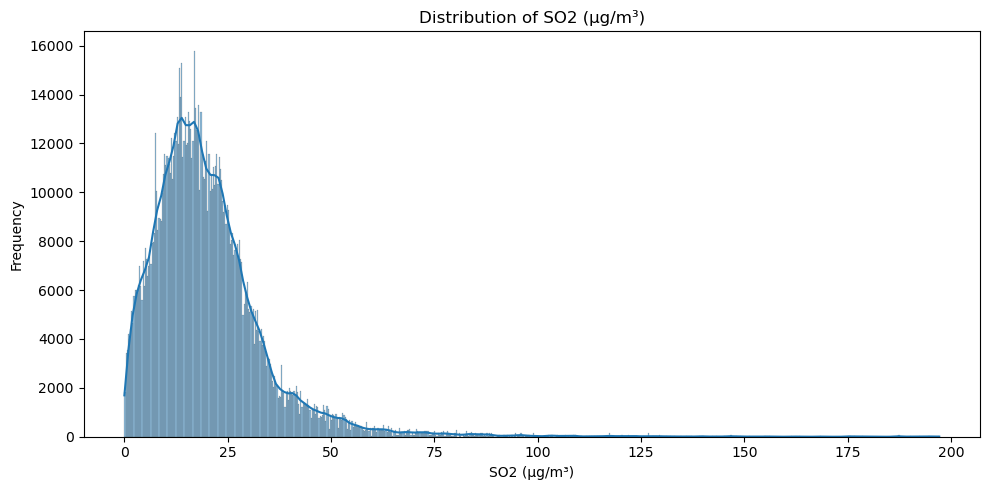

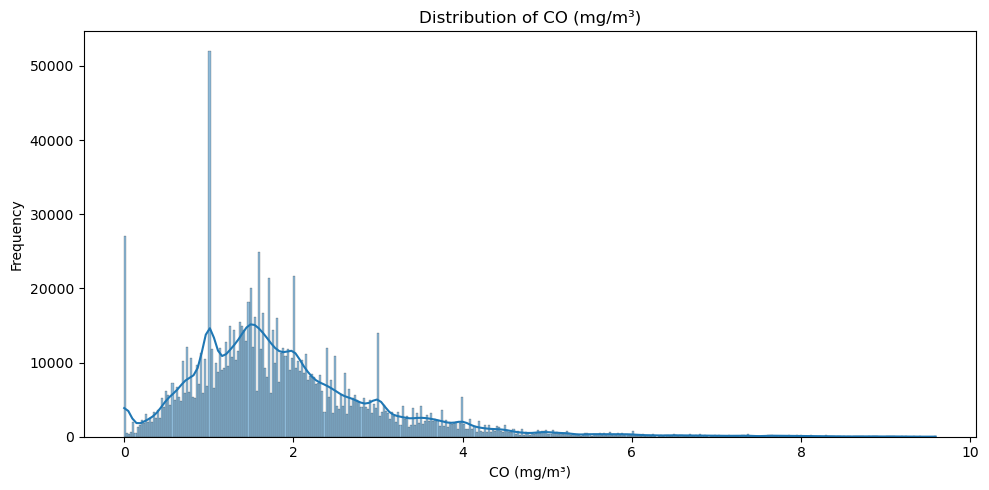

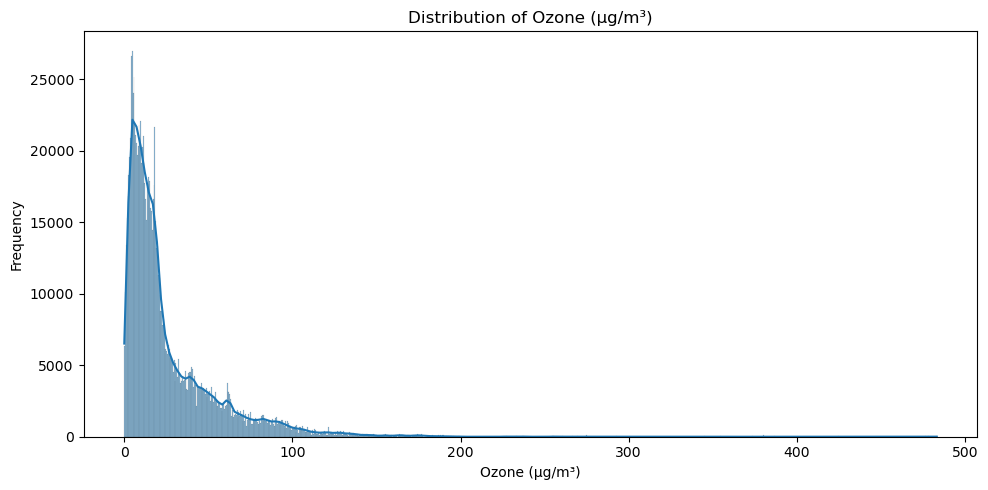

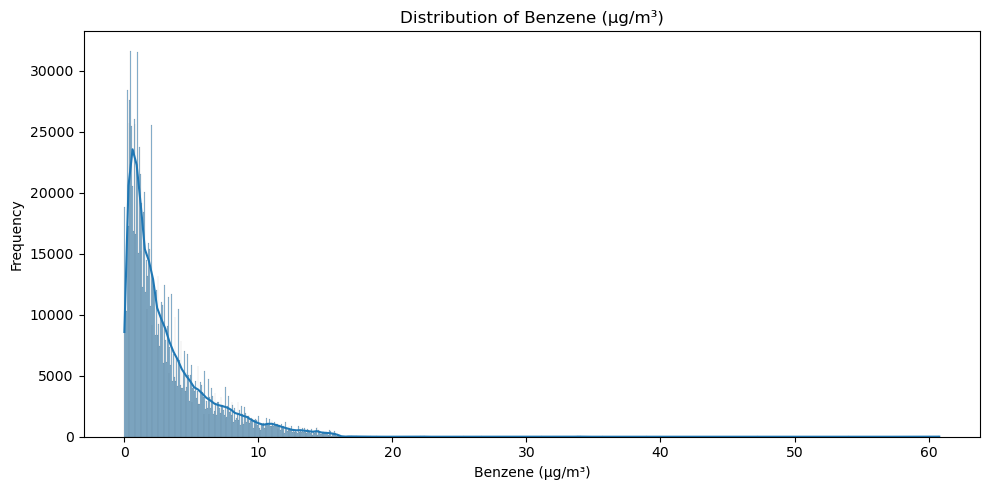

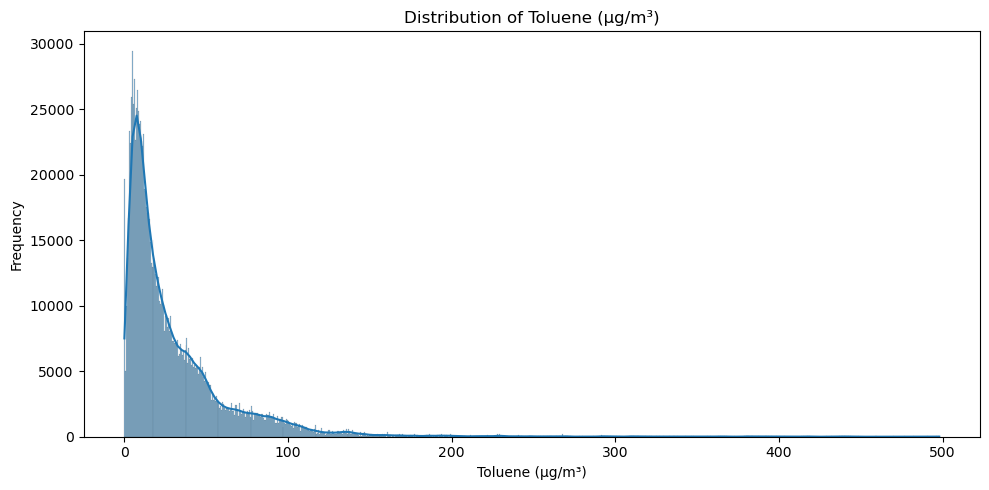

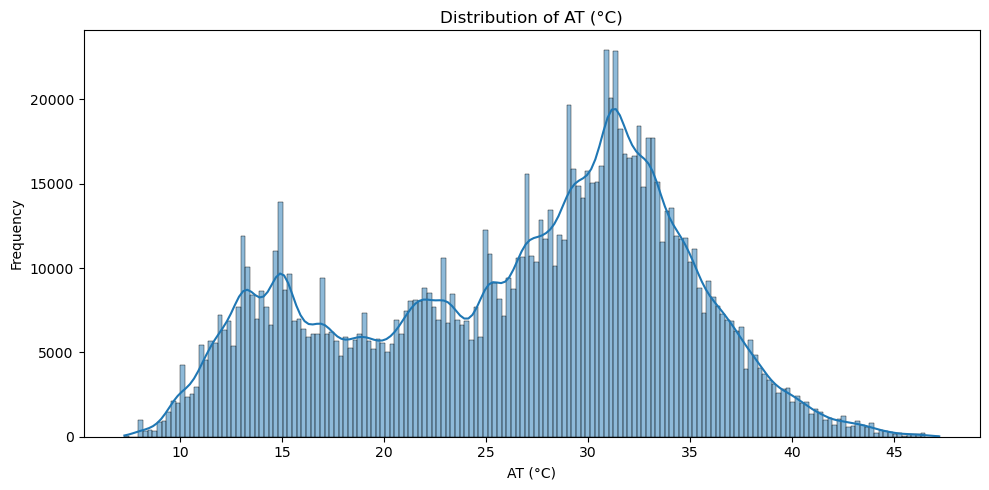

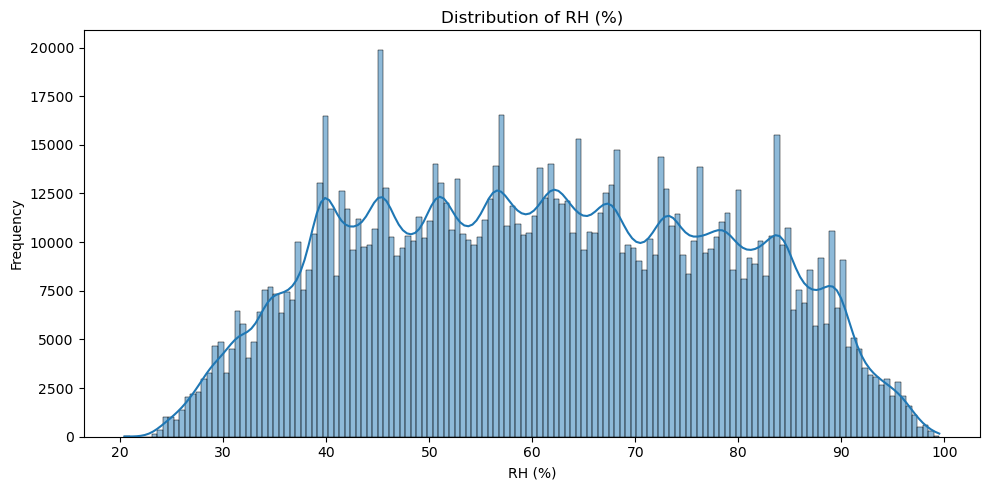

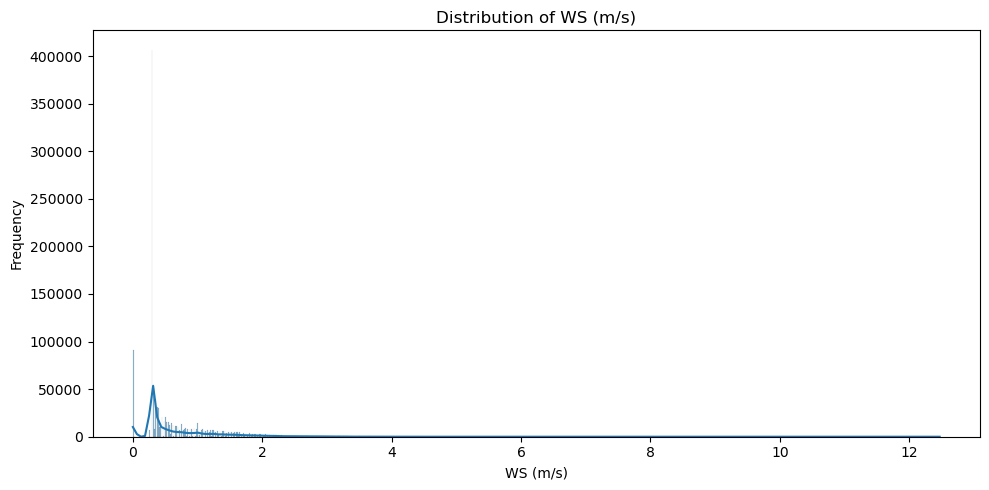

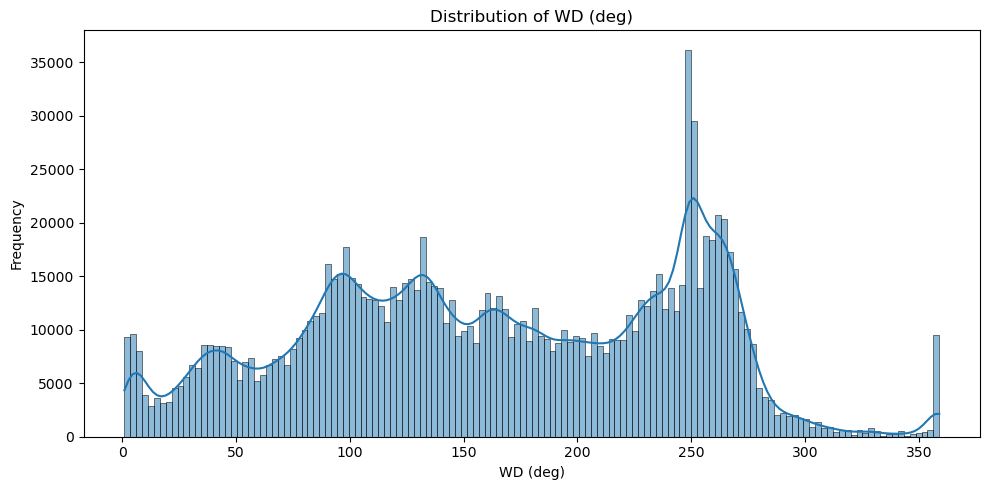

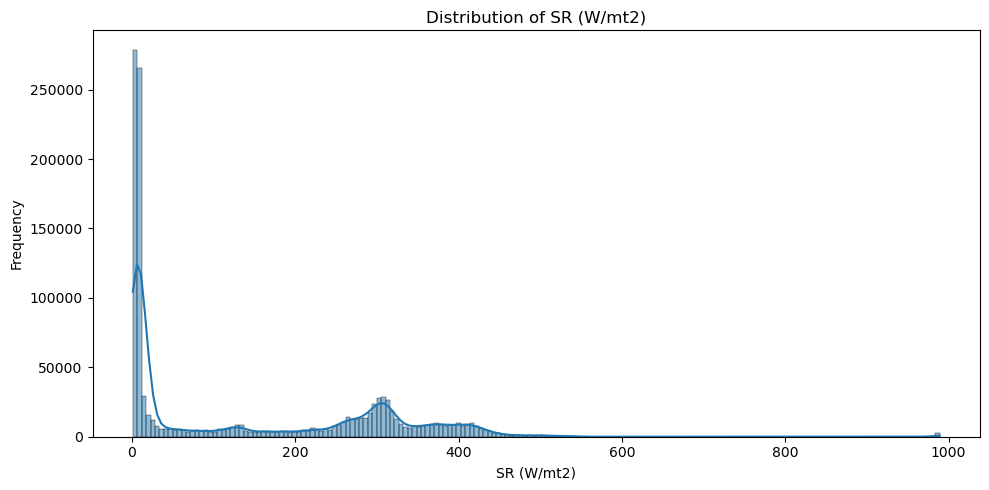

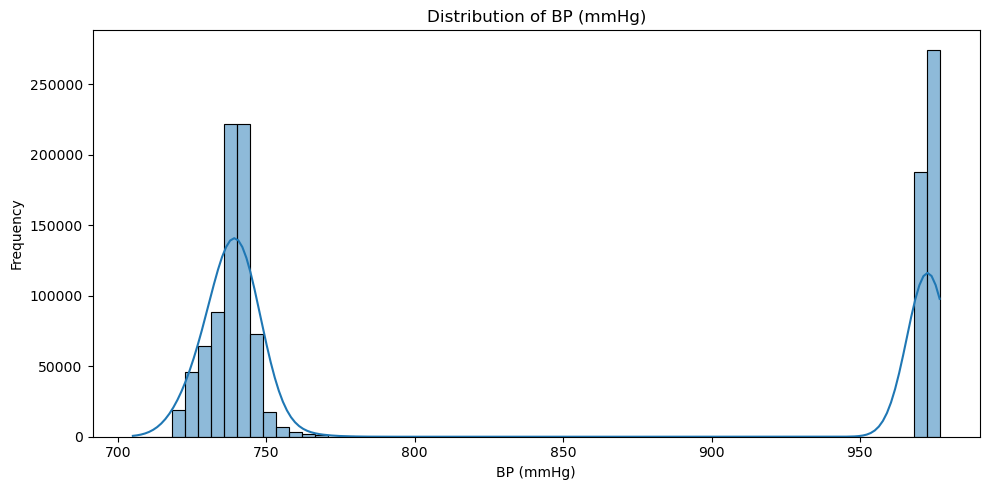

In [210]:
import re

for col in final_df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(10, 5))
    
    sns.histplot(final_df[col].dropna(), kde=True)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    
    # Make column name safe for Windows filenames
    safe_col = re.sub(r'[<>:"/\\|?*]', '_', str(col))
    
    plt.savefig(
        f"distribution_{safe_col}.png",
        dpi=1000,
        bbox_inches="tight"
    )
    
    plt.show()
    plt.close()

### training models

In [85]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.model_selection import train_test_split

In [28]:
features=final_df.drop(['PM2.5 (µg/m³)'],axis=1)
features

,location,Timestamp,PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Toluene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),SR (W/mt2),BP (mmHg)
0,0,1,374.0,102.03,58.83,114.27,74.83,13.20,2.81,1.93,6.23,46.30,11.10,89.00,0.33,251.00,5.00,740.00
1,0,1,437.0,102.10,61.60,115.80,74.32,12.35,2.74,3.05,6.25,45.60,10.85,89.75,0.35,251.00,5.00,740.00
2,0,1,326.0,59.90,63.22,82.35,81.50,14.50,2.38,4.08,5.72,42.88,11.08,89.25,0.68,251.00,5.00,740.00
3,0,1,324.0,44.08,61.25,68.40,70.03,16.45,2.00,2.50,6.00,38.80,11.40,86.50,1.05,251.00,5.00,740.00
4,0,1,381.0,31.90,51.35,53.25,66.12,15.75,1.81,2.55,5.72,36.35,11.42,85.50,0.60,251.00,5.00,740.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1228000,43,8,489.0,50.43,36.03,60.15,36.70,15.28,1.11,10.15,0.13,6.18,33.15,60.25,0.33,144.25,27.25,729.25
1228001,43,8,497.0,64.95,31.25,69.45,31.25,21.60,1.44,10.35,0.23,5.15,32.58,62.50,0.33,142.50,26.50,729.00
1228002,43,8,432.0,132.05,24.93,120.73,29.50,24.33,1.71,10.65,1.03,9.38,32.43,63.00,0.30,140.75,25.50,729.00
1228003,43,8,406.0,82.35,24.83,80.18,28.08,23.35,1.76,10.83,0.75,12.60,32.43,65.75,0.30,142.75,25.25,728.75


In [29]:
target=pd.DataFrame(final_df['PM2.5 (µg/m³)'])
target

,PM2.5 (µg/m³)
0,251.00
1,269.00
2,238.00
3,227.00
4,286.00
...,...
1228000,30.75
1228001,35.75
1228002,48.75
1228003,76.25


In [176]:
xtrain, xtest, ytrain, ytest = train_test_split(features, target, test_size=0.1, random_state=42)

In [177]:
len(xtrain),len(xtest)

(1105204, 122801)

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [87]:
import joblib
import warnings

In [88]:
# Results DataFrame
model_results = pd.DataFrame(columns=[
    "Model",
    "Train_MAE", "Test_MAE",
    "Train_MSE", "Test_MSE",
    "Train_RMSE", "Test_RMSE",
    "Train_R2", "Test_R2"
])


In [89]:
def clasicalmodels(model,path, xtrain=xtrain, ytrain=ytrain, xtest=xtest, ytest=ytest):
    
    warnings.filterwarnings('ignore')
    
    # Train
    model.fit(xtrain, ytrain)
    
    # Prediction
    ypred_train = model.predict(xtrain)
    ypred_test = model.predict(xtest)
    
    print(model, ':')
    
    # Convert target to 1D arrays
    ytrain_array = np.asarray(ytrain).ravel()
    ytest_array = np.asarray(ytest).ravel()
    ypred_train = np.asarray(ypred_train).ravel()
    ypred_test = np.asarray(ypred_test).ravel()
    
    # MAE
    tr_mae = mean_absolute_error(ytrain_array, ypred_train)
    te_mae = mean_absolute_error(ytest_array, ypred_test)
    
    # MSE
    tr_mse = mean_squared_error(ytrain_array, ypred_train)
    te_mse = mean_squared_error(ytest_array, ypred_test)
    
    # RMSE
    tr_rmse = np.sqrt(tr_mse)
    te_rmse = np.sqrt(te_mse)
    
    # R2
    tr_r2 = r2_score(ytrain_array, ypred_train)
    te_r2 = r2_score(ytest_array, ypred_test)
    
    # Print results
    print(f"Train MAE  : {tr_mae:.4f}")
    print(f"Test  MAE  : {te_mae:.4f}")
    print(f"Train MSE  : {tr_mse:.4f}")
    print(f"Test  MSE  : {te_mse:.4f}")
    print(f"Train RMSE : {tr_rmse:.4f}")
    print(f"Test  RMSE : {te_rmse:.4f}")
    print(f"Train R2   : {tr_r2:.4f}")
    print(f"Test  R2   : {te_r2:.4f}")
    
    # Store results
    model_results.loc[len(model_results)] = [
        path,
        tr_mae, te_mae,
        tr_mse, te_mse,
        tr_rmse, te_rmse,
        tr_r2, te_r2
    ]
    
    # Residuals
    train_residuals = ytrain_array - ypred_train
    test_residuals = ytest_array - ypred_test
    
    # Residual plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(
        ypred_train,
        train_residuals,
        s=1,
        alpha=0.1
    )
    axes[0].axhline(0, linestyle='--')
    axes[0].set_title("Train Residual Plot")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Residual (Actual - Predicted)")
    
    axes[1].scatter(
        ypred_test,
        test_residuals,
        s=1,
        alpha=0.1
    )
    axes[1].axhline(0, linestyle='--')
    axes[1].set_title("Test Residual Plot")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    
    plt.tight_layout()
    plt.show()
    
    # Save model
    from pathlib import Path
    
    root = Path("models")
    root.mkdir(exist_ok=True)
    
    path = root / f"{path}.pkl"
    joblib.dump(model, path)
    
    return model

DecisionTreeRegressor(max_depth=5, min_samples_leaf=2, random_state=42) :
Train MAE  : 31.7037
Test  MAE  : 31.5991
Train MSE  : 2202.2294
Test  MSE  : 2194.6558
Train RMSE : 46.9279
Test  RMSE : 46.8472
Train R2   : 0.7890
Test  R2   : 0.7911


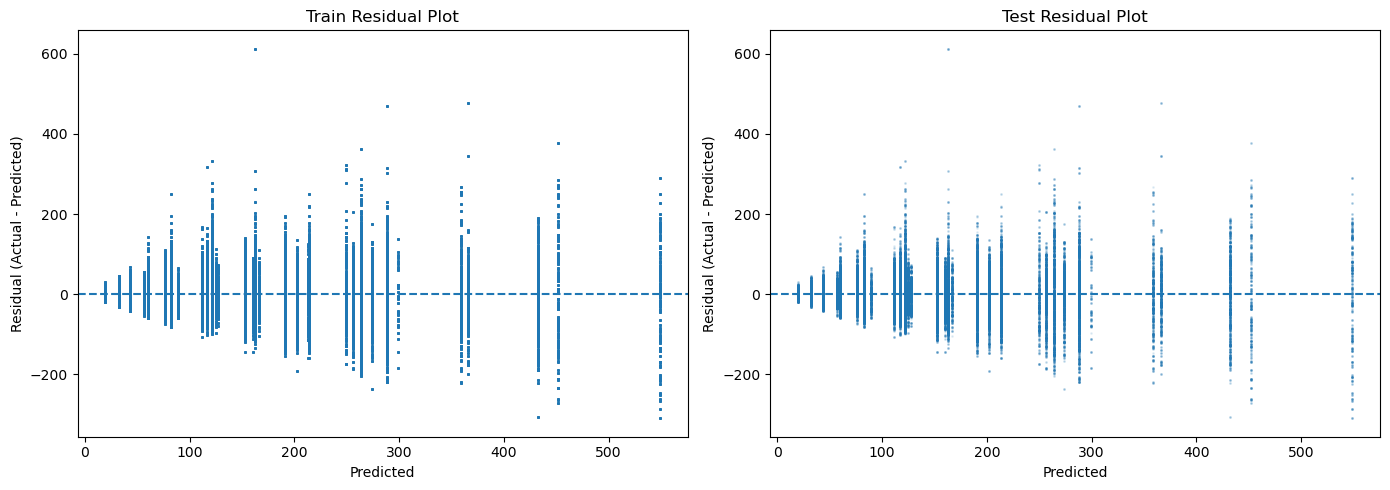

In [90]:
# DecisionTree
decitree=clasicalmodels(DecisionTreeRegressor(criterion='squared_error', max_depth=5, min_samples_leaf=2,random_state=42),path='DTR')

RandomForestRegressor(n_estimators=5, random_state=86) :
Train MAE  : 0.0000
Test  MAE  : 0.0000
Train MSE  : 0.0000
Test  MSE  : 0.0000
Train RMSE : 0.0000
Test  RMSE : 0.0000
Train R2   : 1.0000
Test  R2   : 1.0000


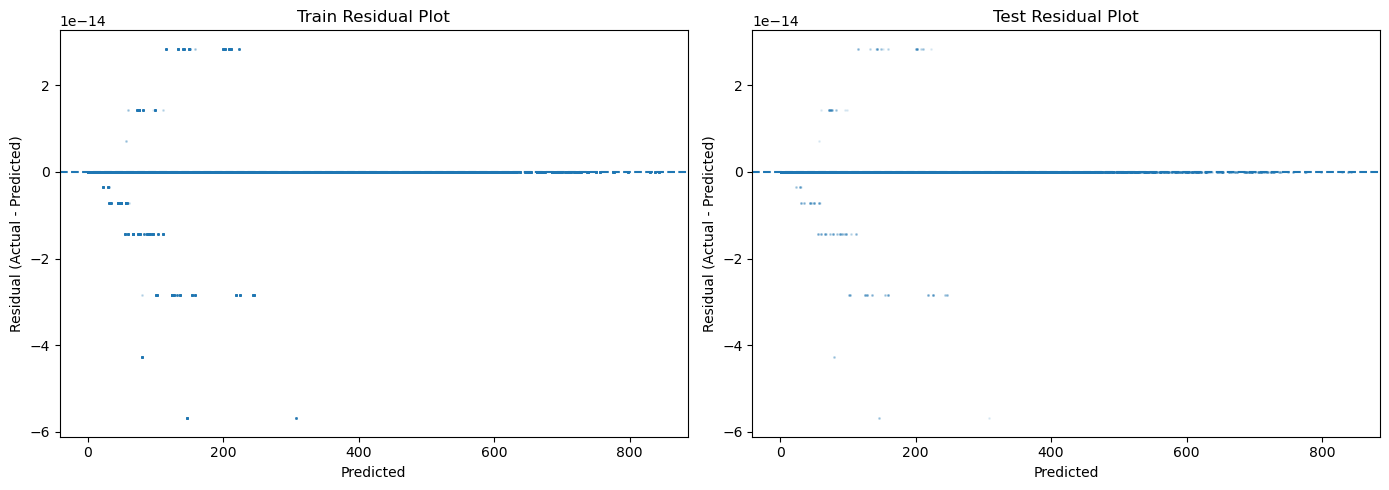

In [91]:
# RandomForest
warnings.filterwarnings('ignore')
ranfor=clasicalmodels(RandomForestRegressor(n_estimators=5,random_state=86),path='RFR')

LinearRegression() :
Train MAE  : 32.3218
Test  MAE  : 32.3615
Train MSE  : 2209.9164
Test  MSE  : 2235.8970
Train RMSE : 47.0097
Test  RMSE : 47.2853
Train R2   : 0.7883
Test  R2   : 0.7872


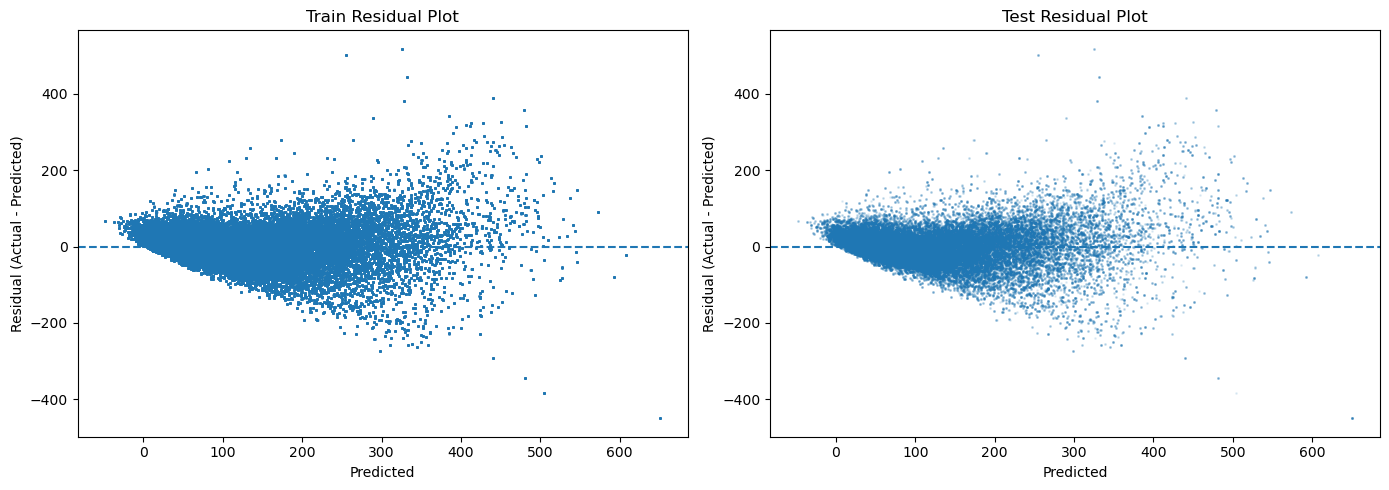

In [92]:
# LinearRegression
warnings.filterwarnings('ignore')
linreg=clasicalmodels(LinearRegression(),path='LR')

Lasso() :
Train MAE  : 32.2699
Test  MAE  : 32.3099
Train MSE  : 2211.7794
Test  MSE  : 2237.6269
Train RMSE : 47.0296
Test  RMSE : 47.3036
Train R2   : 0.7881
Test  R2   : 0.7870


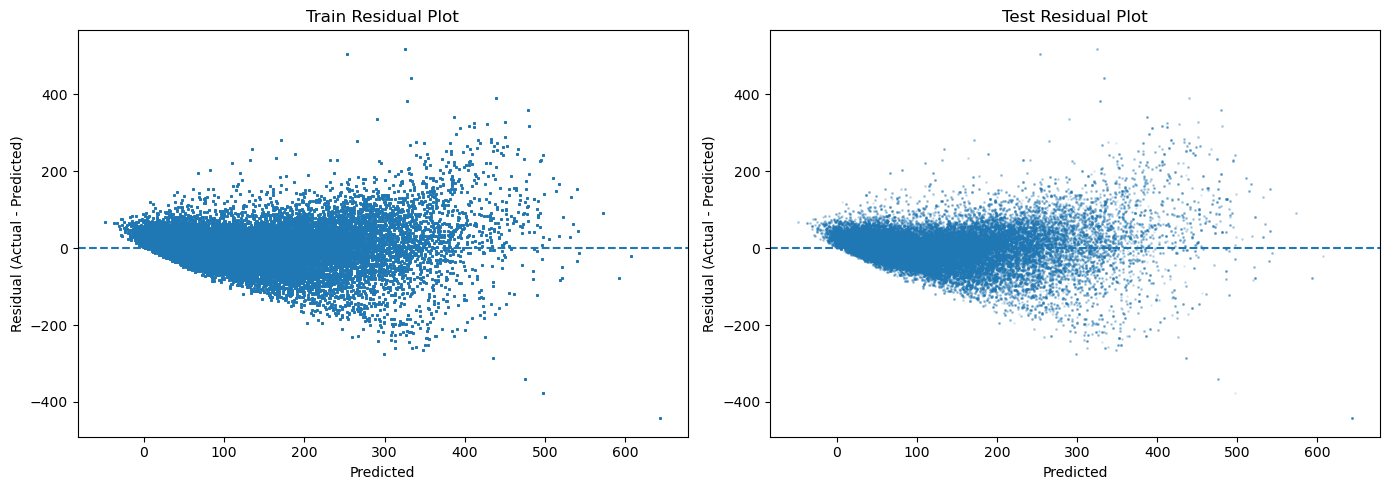

In [93]:
# Lasso Regression
warnings.filterwarnings('ignore')
lasso=clasicalmodels(Lasso(),path='Lasso')

Ridge() :
Train MAE  : 32.3218
Test  MAE  : 32.3615
Train MSE  : 2209.9164
Test  MSE  : 2235.8970
Train RMSE : 47.0097
Test  RMSE : 47.2853
Train R2   : 0.7883
Test  R2   : 0.7872


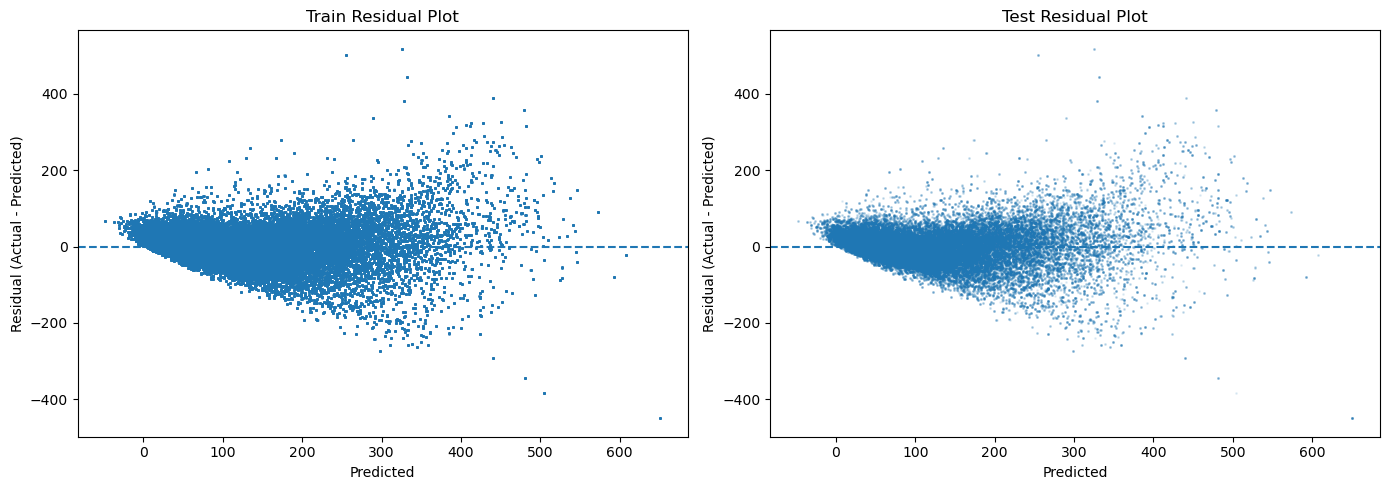

In [94]:
# Ridge Regression
warnings.filterwarnings('ignore')
ridge=clasicalmodels(Ridge(),path='Ridge')

In [95]:
# BaggingClassifier

In [96]:
def clasicalmodels(model,pathname=None,xtrain=xtrain,ytrain=ytrain,xtest=xtest,ytest=ytest):
    if pathname is not None:
        pass
    else:
        pathname = model.__class__.__name__

    model.fit(xtrain, ytrain)
    ypred_train = model.predict(xtrain)
    ypred_test = model.predict(xtest)
    print(model,':')
    
    ytrain = np.asarray(ytrain).ravel()
    ytest = np.asarray(ytest).ravel()
    ypred_train = np.asarray(ypred_train).ravel()
    ypred_test = np.asarray(ypred_test).ravel()
    
    tr_mae = mean_absolute_error(ytrain, ypred_train)
    te_mae = mean_absolute_error(ytest, ypred_test)
    tr_mse = mean_squared_error(ytrain, ypred_train)
    te_mse = mean_squared_error(ytest, ypred_test)
    tr_rmse = np.sqrt(tr_mse)
    te_rmse = np.sqrt(te_mse)
    tr_r2 = r2_score(ytrain, ypred_train)
    te_r2 = r2_score(ytest, ypred_test)
    
    print(f"Train MAE  : {tr_mae:.4f}")
    print(f"Test  MAE  : {te_mae:.4f}")
    print(f"Train MSE  : {tr_mse:.4f}")
    print(f"Test  MSE  : {te_mse:.4f}")
    print(f"Train RMSE : {tr_rmse:.4f}")
    print(f"Test  RMSE : {te_rmse:.4f}")
    print(f"Train R2   : {tr_r2:.4f}")
    print(f"Test  R2   : {te_r2:.4f}")

    model_results.loc[len(model_results)] = [
        pathname,
        tr_mae, te_mae,
        tr_mse, te_mse,
        tr_rmse, te_rmse,
        tr_r2, te_r2
    ]

    train_residuals = ytrain - ypred_train
    test_residuals = ytest - ypred_test

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(
        ypred_train,
        train_residuals,
        s=1,
        alpha=0.1
    )
    axes[0].axhline(0, linestyle='--')
    axes[0].set_title("Train Residual Plot")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Residual (Actual - Predicted)")
    
    axes[1].scatter(
        ypred_test,
        test_residuals,
        s=1,
        alpha=0.1
    )
    axes[1].axhline(0, linestyle='--')
    axes[1].set_title("Test Residual Plot")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    
    plt.tight_layout()
    plt.show()
        
    from pathlib import Path
    root=Path("models")
    root.mkdir(exist_ok=True)
    path = root / f"{str(pathname)}.pkl"
    joblib.dump(model, path)

    return model

AdaBoostRegressor(learning_rate=0.5, n_estimators=5, random_state=42) :
Train MAE  : 36.9836
Test  MAE  : 36.9432
Train MSE  : 2620.5365
Test  MSE  : 2615.1880
Train RMSE : 51.1912
Test  RMSE : 51.1389
Train R2   : 0.7490
Test  R2   : 0.7511


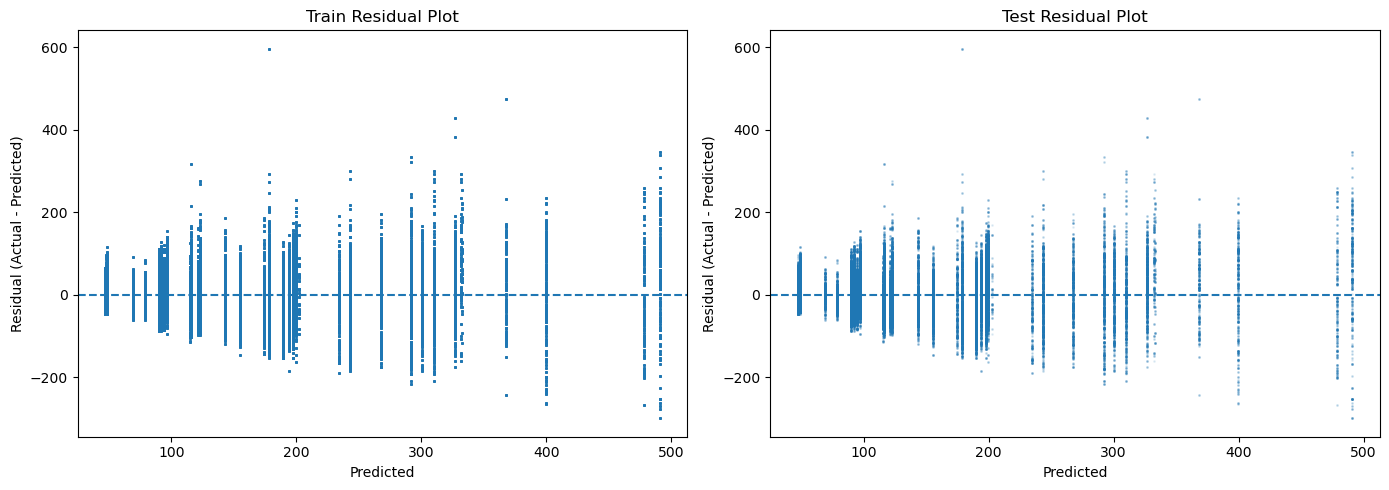

In [97]:
# AdaBoostRegressor
warnings.filterwarnings('ignore')
adaboost=clasicalmodels(AdaBoostRegressor(n_estimators=5,learning_rate=0.5,random_state=42),'ABR')

GradientBoostingRegressor(max_depth=6, n_estimators=5, random_state=42) :
Train MAE  : 50.7053
Test  MAE  : 50.7736
Train MSE  : 4732.6536
Test  MSE  : 4765.5569
Train RMSE : 68.7943
Test  RMSE : 69.0330
Train R2   : 0.5467
Test  R2   : 0.5464


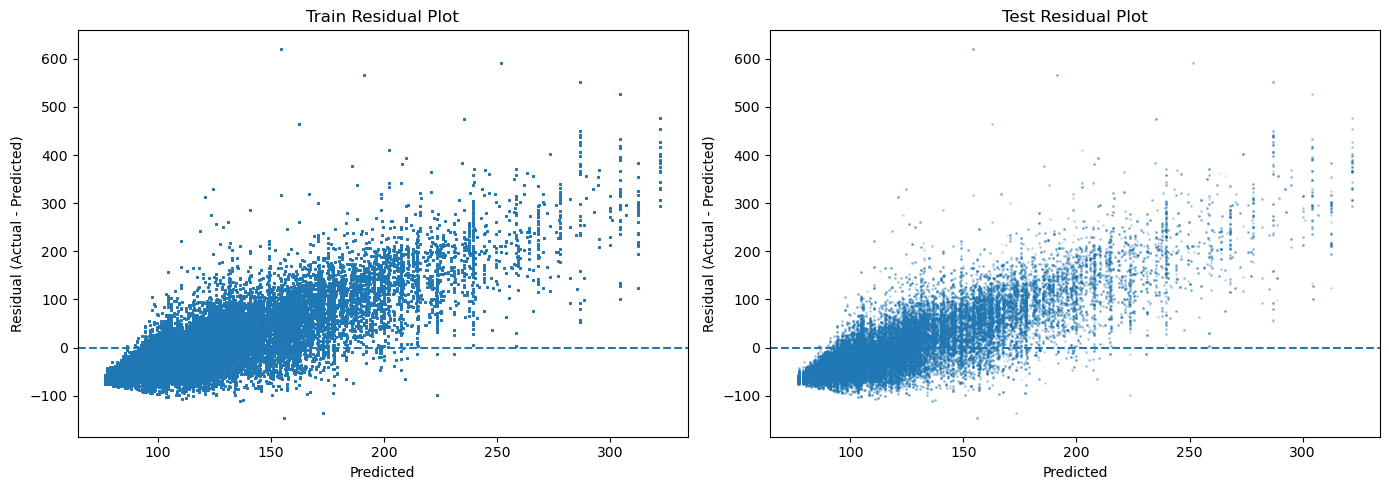

In [98]:
# GradientBoostingRegressor
warnings.filterwarnings('ignore')
gradc=clasicalmodels(GradientBoostingRegressor(n_estimators=5,learning_rate=0.1,max_depth=6,random_state=42),'GBR')

BaggingRegressor(estimator=LinearRegression(), n_estimators=5) :
Train MAE  : 32.3199
Test  MAE  : 32.3600
Train MSE  : 2209.9243
Test  MSE  : 2235.9707
Train RMSE : 47.0098
Test  RMSE : 47.2861
Train R2   : 0.7883
Test  R2   : 0.7872


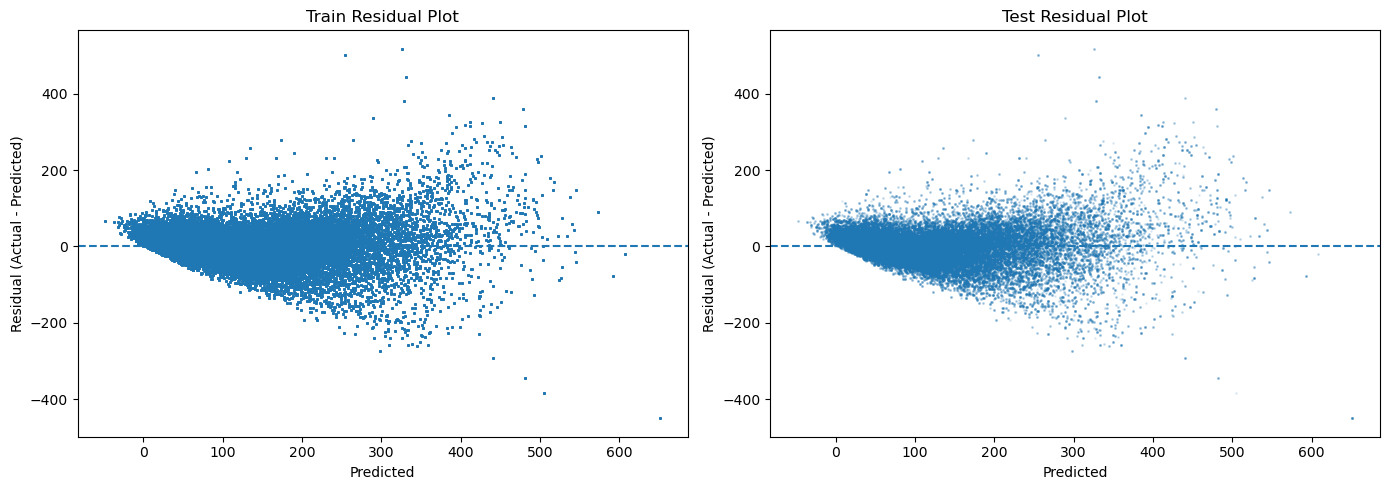

In [99]:
# BaggingRegressor_LinearRegression
warnings.filterwarnings('ignore')
bag_logr=clasicalmodels(BaggingRegressor(n_estimators=5,estimator=linreg),'BLR')

BaggingRegressor(estimator=Ridge(), n_estimators=5) :
Train MAE  : 32.3260
Test  MAE  : 32.3654
Train MSE  : 2209.9271
Test  MSE  : 2235.8330
Train RMSE : 47.0099
Test  RMSE : 47.2846
Train R2   : 0.7883
Test  R2   : 0.7872


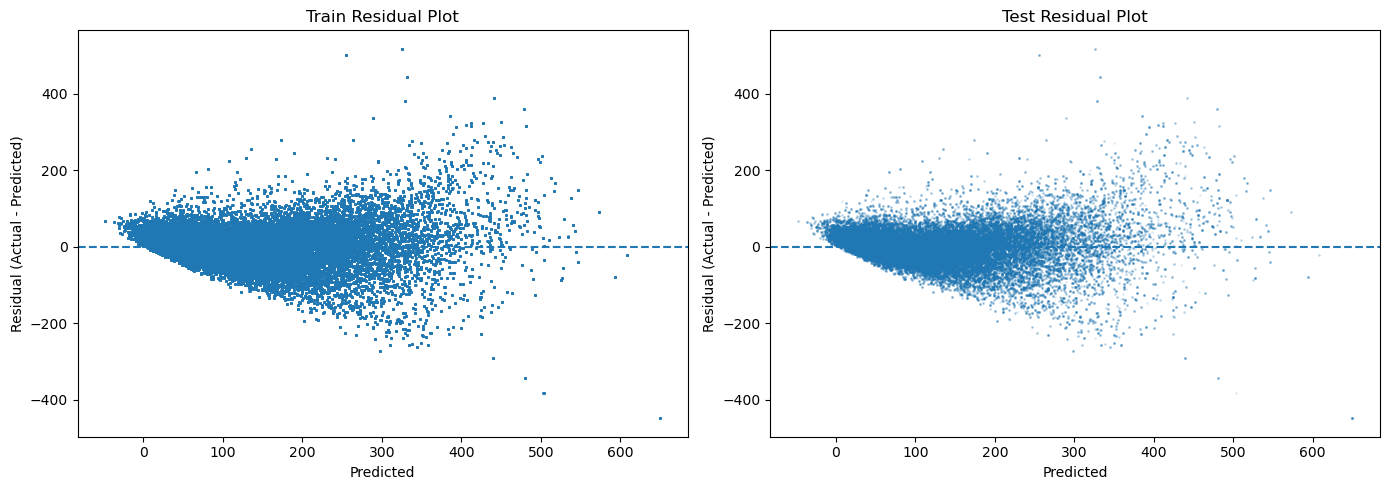

In [156]:
# BaggingRegressor_LinearRegression
warnings.filterwarnings('ignore')
bag_ridge=clasicalmodels(BaggingRegressor(n_estimators=5,estimator=ridge),'BRidge')

BaggingRegressor(estimator=Lasso(), n_estimators=5) :
Train MAE  : 32.2680
Test  MAE  : 32.3084
Train MSE  : 2211.7602
Test  MSE  : 2237.7259
Train RMSE : 47.0294
Test  RMSE : 47.3046
Train R2   : 0.7881
Test  R2   : 0.7870


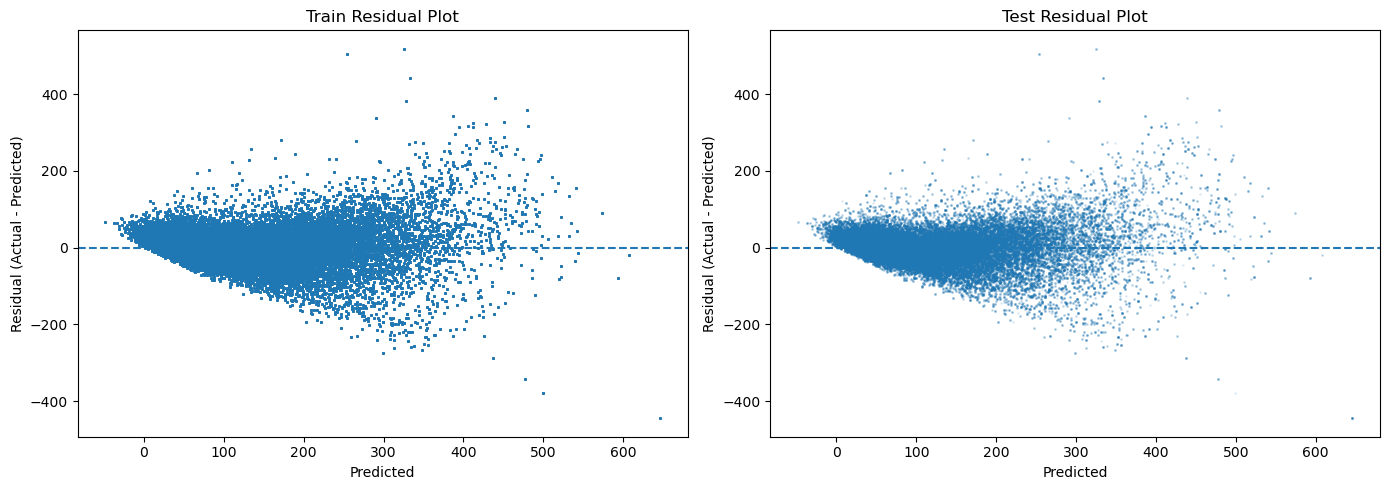

In [157]:
# BaggingRegressor_LinearRegression
warnings.filterwarnings('ignore')
bag_lasso=clasicalmodels(BaggingRegressor(n_estimators=5,estimator=lasso),'BLasso')

In [103]:
print(model_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

 Model  Train_MAE  Test_MAE  Train_MSE  Test_MSE  Train_RMSE  Test_RMSE  Train_R2  Test_R2
   DTR     31.704    31.599   2202.229  2194.656      46.928     46.847     0.789    0.791
   RFR      0.000     0.000      0.000     0.000       0.000      0.000     1.000    1.000
    LR     32.322    32.361   2209.916  2235.897      47.010     47.285     0.788    0.787
 Lasso     32.270    32.310   2211.779  2237.627      47.030     47.304     0.788    0.787
 Ridge     32.322    32.361   2209.916  2235.897      47.010     47.285     0.788    0.787
   ABR     36.984    36.943   2620.537  2615.188      51.191     51.139     0.749    0.751
   GBR     50.705    50.774   4732.654  4765.557      68.794     69.033     0.547    0.546
   BLR     32.320    32.360   2209.924  2235.971      47.010     47.286     0.788    0.787
BRidge     32.321    32.360   2209.924  2235.859      47.010     47.285     0.788    0.787
BLasso     32.274    32.314   2211.677  2237.547      47.028     47.303     0.788    0.787

In [121]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [122]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [133]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(18, 256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


In [134]:
FNN_model = FFN()
FNN_model.to(device)

FFN(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): ReLU()
    (10): Linear(in_features=512, out_features=256, bias=True)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): ReLU()
    (14): Linear(in_features=128, out_features=64, bias=True)
    (15): ReLU()
    (16): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [178]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values.squeeze(), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [179]:
train_dataset = CustomDataset(xtrain,ytrain)

In [180]:
test_dataset = CustomDataset(xtest,ytest)

In [181]:
train_dataloader = DataLoader(train_dataset, batch_size=2000, shuffle=True)

In [182]:
test_dataloader = DataLoader(test_dataset, batch_size=2000, shuffle=True)

In [140]:
def train(model, epochs, train_dataloader=train_dataloader, device=device):
    torch.cuda.manual_seed_all(33)

    for epoch in range(epochs):
        model.train()
        avg_loss = 0.0
        avg_r2   = 0.0

        for step, (x, y) in enumerate(train_dataloader):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)              # shape: [B, 1]
            logits = logits.squeeze(-1)    # shape: [B]
            y = y.float().view(-1)         # shape: [B]

            loss = loss_fn(logits, y)

            loss.backward()
            optimizer.step()

            preds = logits.detach().cpu().numpy()
            actual = y.detach().cpu().numpy()

            r2 = r2_score(actual, preds)

            avg_loss += loss.item()
            avg_r2   += r2

        avg_loss /= (step + 1)
        avg_r2   /= (step + 1)

        print(f"Epoch {epoch} | Avg Loss {avg_loss:.4f} | Avg R2 {avg_r2:.4f}")


In [141]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(FNN_model.parameters(), lr=0.001)

In [142]:
%%time
train(model=FNN_model,epochs=100)

Epoch 0 | Avg Loss 2433.1144 | Avg R2 0.7669
Epoch 1 | Avg Loss 1360.5343 | Avg R2 0.8693
Epoch 2 | Avg Loss 1161.5362 | Avg R2 0.8885
Epoch 3 | Avg Loss 990.6047 | Avg R2 0.9049
Epoch 4 | Avg Loss 826.1775 | Avg R2 0.9207
Epoch 5 | Avg Loss 662.7035 | Avg R2 0.9363
Epoch 6 | Avg Loss 541.8503 | Avg R2 0.9479
Epoch 7 | Avg Loss 411.8492 | Avg R2 0.9604
Epoch 8 | Avg Loss 275.8710 | Avg R2 0.9735
Epoch 9 | Avg Loss 229.1361 | Avg R2 0.9780
Epoch 10 | Avg Loss 146.8371 | Avg R2 0.9859
Epoch 11 | Avg Loss 120.0406 | Avg R2 0.9885
Epoch 12 | Avg Loss 134.4764 | Avg R2 0.9871
Epoch 13 | Avg Loss 59.9926 | Avg R2 0.9942
Epoch 14 | Avg Loss 65.5022 | Avg R2 0.9937
Epoch 15 | Avg Loss 48.3610 | Avg R2 0.9953
Epoch 16 | Avg Loss 58.3226 | Avg R2 0.9944
Epoch 17 | Avg Loss 40.1264 | Avg R2 0.9961
Epoch 18 | Avg Loss 48.6042 | Avg R2 0.9953
Epoch 19 | Avg Loss 29.7770 | Avg R2 0.9971
Epoch 20 | Avg Loss 27.9041 | Avg R2 0.9973
Epoch 21 | Avg Loss 924.1776 | Avg R2 0.9111
Epoch 22 | Avg Loss 465.7

In [143]:
xtrain = torch.tensor(xtrain.values, dtype=torch.float32)
xtest  = torch.tensor(xtest.values,  dtype=torch.float32)
ytrain = torch.tensor(ytrain.values, dtype=torch.long)
ytest  = torch.tensor(ytest.values,  dtype=torch.long)

In [144]:
xtrain = xtrain.to(device)
ytrain = ytrain.to(device)
xtest = xtest.to(device)
ytest = ytest.to(device)


In [145]:
def evaluate_model(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            p = model(x).squeeze(-1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(p.cpu().numpy())

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mse = mean_squared_error(y_true, y_pred)

    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "mse": mse,
        "rmse": np.sqrt(mse),
        "r2": r2_score(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred
    }


In [158]:
def plot_and_store(model, train_loader, test_loader, device, model_results, name="FNN"):
    tr = evaluate_model(model, train_loader, device)
    te = evaluate_model(model, test_loader, device)

    print("Train MAE :", tr["mae"])
    print("Test  MAE :", te["mae"])
    print("Train MSE :", tr["mse"])
    print("Test  MSE :", te["mse"])
    print("Train RMSE:", tr["rmse"])
    print("Test  RMSE:", te["rmse"])
    print("Train R2  :", tr["r2"])
    print("Test  R2  :", te["r2"])

    model_results.loc[len(model_results)] = [
        name,
        tr["mae"], te["mae"],
        tr["mse"], te["mse"],
        tr["rmse"], te["rmse"],
        tr["r2"], te["r2"]
    ]

    train_residuals = tr["y_true"] - tr["y_pred"]
    test_residuals = te["y_true"] - te["y_pred"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(
        tr["y_pred"],
        train_residuals,
        s=1,
        alpha=0.1
    )
    axes[0].axhline(0, linestyle='--')
    axes[0].set_title("Train Residual Plot")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Residual (Actual - Predicted)")
    
    axes[1].scatter(
        te["y_pred"],
        test_residuals,
        s=1,
        alpha=0.1
    )
    axes[1].axhline(0, linestyle='--')
    axes[1].set_title("Test Residual Plot")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    
    plt.tight_layout()
    plt.show()

Train MAE : 1.7069646120071411
Test  MAE : 1.7195348739624023
Train MSE : 6.291688442230225
Test  MSE : 6.549892425537109
Train RMSE: 2.508323831212833
Test  RMSE: 2.559275761917248
Train R2  : 0.9993973970413208
Test  R2  : 0.999376654624939


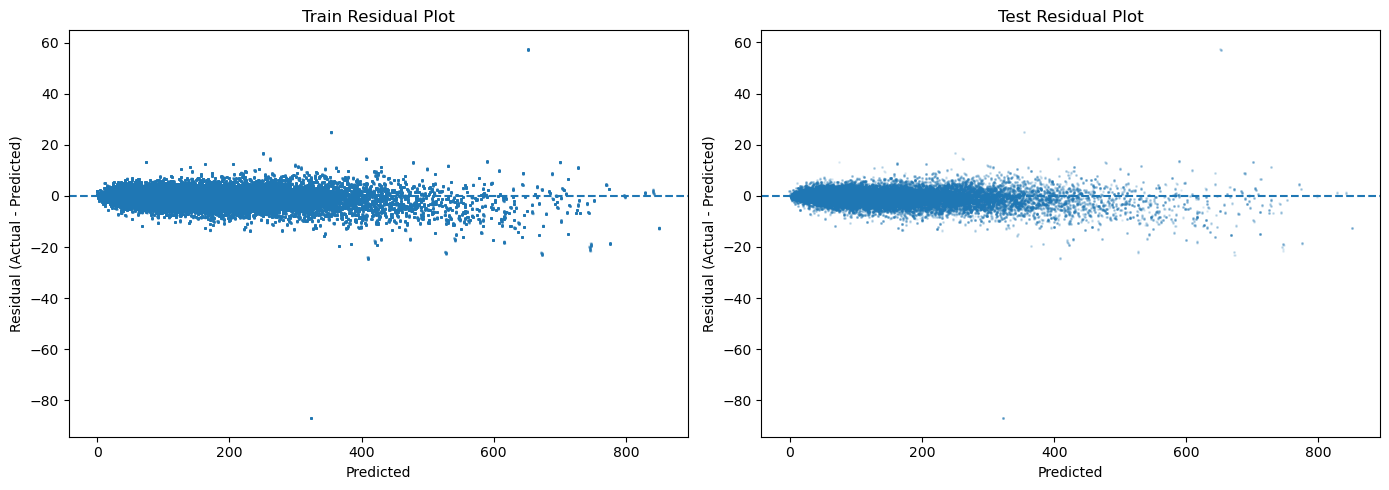

In [159]:
plot_and_store(
    FNN_model,
    train_dataloader,
    test_dataloader,
    device,
    model_results,
    "FNN"
)

In [162]:
print(model_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

 Model  Train_MAE  Test_MAE  Train_MSE  Test_MSE  Train_RMSE  Test_RMSE  Train_R2  Test_R2
   DTR     31.704    31.599   2202.229  2194.656      46.928     46.847     0.789    0.791
   RFR      0.000     0.000      0.000     0.000       0.000      0.000     1.000    1.000
    LR     32.322    32.361   2209.916  2235.897      47.010     47.285     0.788    0.787
 Lasso     32.270    32.310   2211.779  2237.627      47.030     47.304     0.788    0.787
 Ridge     32.322    32.361   2209.916  2235.897      47.010     47.285     0.788    0.787
   ABR     36.984    36.943   2620.537  2615.188      51.191     51.139     0.749    0.751
   GBR     50.705    50.774   4732.654  4765.557      68.794     69.033     0.547    0.546
   BLR     32.320    32.360   2209.924  2235.971      47.010     47.286     0.788    0.787
BRidge     32.321    32.360   2209.924  2235.859      47.010     47.285     0.788    0.787
BLasso     32.274    32.314   2211.677  2237.547      47.028     47.303     0.788    0.787

## Plots

In [213]:
"""
Four functions, each producing a structurally distinct, publication-grade figure
from the same aggregate metrics table (no raw predictions required):

  1. plot_model_atlas()              -> small-multiple polar "topographic" panels,
                                         one per model, showing 4 normalized metrics
  2. plot_generalization_bump()      -> curved bump/slope chart of Train->Test drift
  3. plot_error_ridgeline()          -> reconstructed error-distribution ridgeline
                                         (KDE-shaded, derived from MAE/RMSE)
  4. plot_bias_variance_topography() -> contour "elevation map" of the
                                         accuracy vs. overfitting trade-off

Each is independently callable and saves a high-resolution PNG.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import skewnorm
from scipy.interpolate import griddata

plt.rcParams["font.family"] = "DejaVu Sans"

FULL_NAMES = {
    "DTR": "Decision Tree",
    "RFR": "Random Forest",
    "LR": "Linear Regression",
    "Lasso": "Lasso",
    "Ridge": "Ridge",
    "ABR": "AdaBoost",
    "GBR": "Gradient Boosting",
    "BLR": "Bagged Linear Reg.",
    "BRidge": "Bagged Ridge",
    "BLasso": "Bagged Lasso",
    "FNN": "FNN (PyTorch)",
}


def load_data() -> pd.DataFrame:
    """Hardcoded metrics table. Swap for pd.read_csv(...) once Roy's 5th model lands."""
    rows = [
        ("DTR",    31.704, 31.599, 2202.229, 2194.656, 46.928, 46.847, 0.789, 0.791),
        ("RFR",     0.000,  0.000,    0.000,    0.000,  0.000,  0.000, 1.000, 1.000),
        ("LR",     32.322, 32.361, 2209.916, 2235.897, 47.010, 47.285, 0.788, 0.787),
        ("Lasso",  32.270, 32.310, 2211.779, 2237.627, 47.030, 47.304, 0.788, 0.787),
        ("Ridge",  32.322, 32.361, 2209.916, 2235.897, 47.010, 47.285, 0.788, 0.787),
        ("ABR",    36.984, 36.943, 2620.537, 2615.188, 51.191, 51.139, 0.749, 0.751),
        ("GBR",    50.705, 50.774, 4732.654, 4765.557, 68.794, 69.033, 0.547, 0.546),
        ("BLR",    32.320, 32.360, 2209.924, 2235.971, 47.010, 47.286, 0.788, 0.787),
        ("BRidge", 32.321, 32.360, 2209.924, 2235.859, 47.010, 47.285, 0.788, 0.787),
        ("BLasso", 32.274, 32.314, 2211.677, 2237.547, 47.028, 47.303, 0.788, 0.787),
        ("FNN",     1.707,  1.720,      6.292,    6.550,  2.508,  2.559, 0.999, 0.999),
    ]
    cols = ["Model", "Train_MAE", "Test_MAE", "Train_MSE", "Test_MSE",
            "Train_RMSE", "Test_RMSE", "Train_R2", "Test_R2"]
    df = pd.DataFrame(rows, columns=cols)
    df["FullName"] = df["Model"].map(FULL_NAMES)
    return df


def compute_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Adds generalization gap and the RMSE/MAE outlier-sensitivity ratio."""
    df = df.copy()
    df["Gap_R2"] = (df["Train_R2"] - df["Test_R2"]).clip(lower=0)
    # RMSE/MAE ratio: 1.0 = perfectly uniform residuals; higher = heavier-tailed
    # errors / occasional large misses (a standard diagnostic, e.g. Chai & Draxler 2014).
    df["RMSE_MAE_Ratio"] = df["Test_RMSE"] / df["Test_MAE"].replace(0, np.nan)
    df["RMSE_MAE_Ratio"] = df["RMSE_MAE_Ratio"].fillna(1.0)
    return df


# ----------------------------------------------------------------------------
# 1. MODEL ATLAS — small-multiple polar "contour" panels, one per model
# ----------------------------------------------------------------------------
def plot_model_atlas(df: pd.DataFrame, save_path: str = "atlas.png"):
    """
    Each model gets its own topographic-style polar panel. Four axes
    (Accuracy, Precision, Robustness, Stability) are normalized 0-1 across
    models so panel *shape*, not just size, is comparable at a glance —
    like contour maps of the same region at different sites.
    """
    axes_labels = ["Accuracy\n(R2)", "Precision\n(1/MAE)", "Robustness\n(1/RMSE)", "Stability\n(1/Gap)"]
    n_axes = len(axes_labels)
    angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
    angles += angles[:1]

    def norm01(s, invert=False):
        s = s.astype(float)
        rng = s.max() - s.min()
        out = (s - s.min()) / rng if rng > 0 else s * 0 + 1.0
        return 1 - out if invert else out

    acc = norm01(df["Test_R2"])
    prec = norm01(df["Test_MAE"], invert=True)
    rob = norm01(df["Test_RMSE"], invert=True)
    stab = norm01(df["Gap_R2"], invert=True)

    n_models = len(df)
    n_cols = 4
    n_rows = int(np.ceil(n_models / n_cols))

    fig = plt.figure(figsize=(15, 3.7 * n_rows))
    fig.patch.set_facecolor("#0b1220")

    cmap = LinearSegmentedColormap.from_list("elev", ["#1b2a4a", "#2a9d8f", "#e9c46a", "#e76f51"])

    for i, (_, row) in enumerate(df.reset_index(drop=True).iterrows()):
        ax = fig.add_subplot(n_rows, n_cols, i + 1, projection="polar")
        ax.set_facecolor("#0b1220")

        vals = [acc[i], prec[i], rob[i], stab[i]]
        vals += vals[:1]
        overall = np.mean(vals[:-1])
        color = cmap(overall)

        # topographic-style concentric contour rings
        for r in np.linspace(0.2, 1.0, 5):
            ax.plot(angles, [r] * len(angles), color="#334", lw=0.5, alpha=0.5, zorder=1)

        ax.fill(angles, vals, color=color, alpha=0.55, zorder=3)
        ax.plot(angles, vals, color=color, lw=2, zorder=4)
        ax.scatter(angles[:-1], vals[:-1], color="white", s=14, zorder=5)

        ax.set_ylim(0, 1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(axes_labels, color="#cbd5e1", fontsize=7.5)
        ax.set_yticklabels([])
        ax.spines["polar"].set_color("#334155")
        ax.grid(color="#334155", alpha=0.3)

        ax.set_title(f"{row['Model']}\n{row['FullName']}", color="white",
                      fontsize=10.5, fontweight="bold", pad=14)

    fig.suptitle("Model Atlas — Normalized Performance Contours by Estimator",
                  color="white", fontsize=16, fontweight="bold", y=1.02)
    fig.text(0.5, 0.995, "Each panel: Accuracy, Precision, Robustness, Stability (0-1, higher = better)",
              color="#94a3b8", fontsize=9.5, ha="center")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(save_path, dpi=1000, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.close(fig)
    return save_path


# ----------------------------------------------------------------------------
# 2. GENERALIZATION BUMP — curved Train -> Test drift chart
# ----------------------------------------------------------------------------
def _bezier(p0, p1, n=60):
    """Horizontal S-curve between two (x, y) points for a smooth bump line."""
    x0, y0 = p0
    x1, y1 = p1
    xm = (x0 + x1) / 2
    verts = [(x0, y0), (xm, y0), (xm, y1), (x1, y1)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    path = Path(verts, codes)
    ts = np.linspace(0, 1, n)
    pts = path.interpolated(n - 1).vertices
    return pts[:, 0], pts[:, 1]


def _declutter_labels(values, min_gap):
    """Greedy 1D collision avoidance: nudges sorted label y-positions apart."""
    order = np.argsort(values)
    positions = np.array(values, dtype=float)[order]
    for i in range(1, len(positions)):
        if positions[i] - positions[i - 1] < min_gap:
            positions[i] = positions[i - 1] + min_gap
    out = np.empty_like(positions)
    out[order] = positions
    return out


def plot_generalization_bump(df: pd.DataFrame, save_path: str = "bump.png"):
    """
    A slope/bump chart connecting each model's Train RMSE to its Test RMSE
    with a smooth S-curve. Near-flat, short curves = well-generalized;
    long curves = train/test drift. A cbrt (cube-root) axis keeps FNN/RFR
    near zero and the ~47-69 cluster both legible on one shared scale, and
    right-side labels are decluttered so tightly-packed models don't overlap.
    """
    d = df.sort_values("Test_RMSE").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11.5, 8))
    fig.patch.set_facecolor("#fbf9f4")
    ax.set_facecolor("#fbf9f4")

    def f(v):
        return np.cbrt(v)

    cmap = plt.get_cmap("cividis")
    n = len(d)

    label_y_raw = f(d["Test_RMSE"].values)
    label_y = _declutter_labels(label_y_raw, min_gap=(f(d["Test_RMSE"].max()) * 0.045))

    for i, row in d.iterrows():
        color = cmap(i / max(n - 1, 1))
        xs, ys = _bezier((0, f(row["Train_RMSE"])), (1, f(row["Test_RMSE"])))
        ax.plot(xs, ys, color=color, lw=2.6, alpha=0.9, zorder=3,
                solid_capstyle="round")
        ax.scatter([0, 1], [f(row["Train_RMSE"]), f(row["Test_RMSE"])],
                   color=color, s=55, zorder=4, edgecolor="white", linewidth=1)
        # leader line from true point to decluttered label position
        ax.plot([1, 1.05], [f(row["Test_RMSE"]), label_y[i]], color=color, lw=0.9, alpha=0.6, zorder=3)
        ax.text(1.07, label_y[i], f"{row['Model']}  ({row['Test_RMSE']:.1f})",
                va="center", fontsize=9.5, color=color, fontweight="bold")
        ax.text(-0.05, f(row["Train_RMSE"]), f"{row['Train_RMSE']:.1f}",
                va="center", ha="right", fontsize=8, color="#555")

    ax.set_xlim(-0.4, 1.9)
    y_top = f(d["Test_RMSE"].max()) * 1.15
    ax.set_ylim(-0.3, max(y_top, label_y.max() * 1.05))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Train RMSE", "Test RMSE"], fontsize=12, fontweight="bold")
    ax.set_yticks([])
    ax.set_ylabel("RMSE  (cube-root scale)", fontsize=11)
    ax.set_title("Generalization Drift — Train → Test RMSE by Model",
                 fontsize=16, fontweight="bold", pad=38)
    ax.text(0.5, 1.055, "Flatter, shorter curves indicate stronger generalization; steep curves flag train/test divergence",
            transform=ax.transAxes, ha="center", fontsize=9.5, color="#666")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#999")

    plt.tight_layout()
    plt.savefig(save_path, dpi=1000, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.close(fig)
    return save_path


# ----------------------------------------------------------------------------
# 3. ERROR RIDGELINE — reconstructed residual-distribution "mountain range"
# ----------------------------------------------------------------------------
def plot_error_ridgeline(df: pd.DataFrame, save_path: str = "ridgeline.png"):
    """
    Raw residuals aren't available, only summary statistics, so each model's
    error distribution is *reconstructed* as a skew-normal whose mean and
    std are matched to Test_MAE and Test_RMSE (RMSE >> MAE implies heavier
    tails / occasional large errors, which sets the skew parameter). This is
    an approximation for visual diagnosis, not a claim about exact residuals.
    """
    d = df.sort_values("Test_RMSE", ascending=False).reset_index(drop=True)
    n = len(d)
    fig, ax = plt.subplots(figsize=(11, 0.85 * n + 2))

    # CHANGED: light background instead of dark black background
    fig.patch.set_facecolor("#fbf9f4")
    ax.set_facecolor("#fbf9f4")

    cmap = plt.get_cmap("magma")
    x_max = float(d["Test_RMSE"].max()) * 2.6 + 5
    x = np.linspace(-x_max * 0.15, x_max, 800)

    for i, row in d.iterrows():
        # floor near-zero errors (e.g. a saturated RFR) so a distribution is still drawable
        mae, rmse = max(row["Test_MAE"], 0.15), max(row["Test_RMSE"], 0.2)
        ratio = rmse / mae
        # method-of-moments-ish mapping: higher ratio -> more skew/heavier tail
        a = np.clip((ratio - 1.0) * 12, 0.5, 30)   # skewness shape
        scale = mae * 0.9
        loc = mae - skewnorm.mean(a, loc=0, scale=scale)
        y = skewnorm.pdf(x, a, loc=loc, scale=scale)
        y = y / y.max() * 0.85  # normalize peak height for ridgeline stacking

        base = i
        color = cmap(0.15 + 0.75 * i / max(n - 1, 1))
        ax.fill_between(x, base, base + y, color=color, alpha=0.85, zorder=n - i, lw=0)
        ax.plot(x, base + y, color="#444444", lw=0.8, alpha=0.7, zorder=n - i + 0.5)
        ax.text(x_max, base + 0.12, f"{row['Model']}", color="#222222",
                fontsize=10, fontweight="bold", va="bottom", ha="left")
        ax.text(x_max, base - 0.05, f"MAE {mae:.1f} | RMSE {rmse:.1f} | ratio {ratio:.2f}",
                color="#666666", fontsize=7.5, va="top", ha="left")

    ax.set_xlim(x[0], x_max * 1.32)
    ax.set_ylim(-0.3, n + 0.3)
    ax.set_yticks([])
    ax.set_xlabel("Reconstructed absolute test error (target units)", color="#333333", fontsize=10.5)
    ax.tick_params(colors="#333333")
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    fig.suptitle("Error Landscape — Reconstructed Test-Error Distributions",
                 color="#222222", fontsize=16, fontweight="bold", y=0.985)
    fig.text(0.5, 0.955, "Shape reconstructed from MAE/RMSE (RMSE/MAE ratio drives tail weight) "
                          "— a proxy for residual distribution, not raw residuals",
             ha="center", fontsize=9.5, color="#666666")
    plt.savefig(save_path, dpi=1000, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.close(fig)
    return save_path


# ----------------------------------------------------------------------------
# 4. BIAS-VARIANCE TOPOGRAPHY — contour "elevation map" of the trade-off
# ----------------------------------------------------------------------------
def plot_bias_variance_topography(df: pd.DataFrame, save_path: str = "topography.png"):
    """
    X = Test R2 (accuracy), Y = generalization gap (Train R2 - Test R2, i.e.
    overfitting risk), bubble size = Test RMSE. A synthetic risk-cost surface
    (accuracy reward minus overfit penalty) is rendered as filled elevation
    contours behind the points so each model's location reads like a site
    marked on a topographic map -- higher illuminated ground = better
    accuracy/generalization trade-off.
    """
    d = df.copy()
    fig, ax = plt.subplots(figsize=(11, 8.5))
    fig.patch.set_facecolor("#f5f2ea")
    ax.set_facecolor("#f5f2ea")

    x_pad = 0.05
    xmin, xmax = d["Test_R2"].min() - x_pad, 1.0 + 0.01
    ymin, ymax = -0.01, d["Gap_R2"].max() + 0.03

    gx, gy = np.meshgrid(np.linspace(xmin, xmax, 300), np.linspace(ymin, ymax, 300))
    # synthetic "elevation": reward high accuracy, penalize overfit gap
    elevation = (gx - xmin) / (xmax - xmin) * 1.0 - (gy - ymin) / (ymax - ymin + 1e-9) * 0.6

    levels = np.linspace(elevation.min(), elevation.max(), 14)
    terrain = LinearSegmentedColormap.from_list(
        "terrain2", ["#5b3a29", "#a98467", "#dad7cd", "#adc178", "#588157", "#344e41"])
    cf = ax.contourf(gx, gy, elevation, levels=levels, cmap=terrain, alpha=0.9, zorder=1)
    ax.contour(gx, gy, elevation, levels=levels, colors="#33333355", linewidths=0.5, zorder=2)

    sizes = 300 + 2600 * (d["Test_RMSE"] - d["Test_RMSE"].min()) / (d["Test_RMSE"].max() - d["Test_RMSE"].min() + 1e-9)
    ax.scatter(d["Test_R2"], d["Gap_R2"], s=sizes, c="#e63946",
               edgecolor="white", linewidth=1.8, zorder=5, alpha=0.92)

    # Several models land on nearly identical coordinates (e.g. LR/Ridge/Lasso and
    # their bagged variants). Cluster near-duplicate points and label the cluster
    # once with a stacked name list instead of overlapping text.
    d["_cx"] = d["Test_R2"].round(3)
    d["_cy"] = d["Gap_R2"].round(3)
    clusters = [(g["Test_R2"].mean(), g["Gap_R2"].mean(), ", ".join(g["Model"]))
                for _, g in d.groupby(["_cx", "_cy"])]
    clusters.sort(key=lambda c: c[0])
    # stagger label height when cluster centers sit within a narrow x-band
    x_span = xmax - xmin
    last_x, level = None, 0
    for idx, (cx, cy, names) in enumerate(clusters):
        if last_x is not None and (cx - last_x) < 0.09 * x_span:
            level += 1
        else:
            level = 0
        last_x = cx
        y_off = 0.014 + level * 0.007
        ax.annotate(names, (cx, cy), xytext=(cx, cy + y_off),
                    ha="center", va="bottom", fontsize=9.5, fontweight="bold",
                    color="#1d1d1d", zorder=6,
                    arrowprops=dict(arrowstyle="-", color="#1d1d1d55", lw=0.8))

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Test R²  (accuracy →)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Generalization Gap = Train R² − Test R²  (overfit risk →)", fontsize=12, fontweight="bold")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    fig.suptitle("Bias–Variance Topography — Accuracy vs. Overfitting Risk",
                 fontsize=16, fontweight="bold", y=0.99)
    fig.text(0.5, 0.945, "Bubble size = Test RMSE  |  brighter terrain = better accuracy/generalization trade-off",
             ha="center", fontsize=9.5, color="#444")
    plt.savefig(save_path, dpi=1000, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.close(fig)
    return save_path


# ----------------------------------------------------------------------------
# Orchestration — function definitions above, calls below
# ----------------------------------------------------------------------------
def main(out_dir="."):
    df = compute_derived_metrics(load_data())

    p1 = plot_model_atlas(df, save_path=f"{out_dir}/1_model_atlas.png")
    p2 = plot_generalization_bump(df, save_path=f"{out_dir}/2_generalization_bump.png")
    p3 = plot_error_ridgeline(df, save_path=f"{out_dir}/3_error_ridgeline.png")
    p4 = plot_bias_variance_topography(df, save_path=f"{out_dir}/4_bias_variance_topography.png")

    print("Saved:", p1, p2, p3, p4)
    return p1, p2, p3, p4


if __name__ == "__main__":
    main(out_dir=".")

Saved: ./1_model_atlas.png ./2_generalization_bump.png ./3_error_ridgeline.png ./4_bias_variance_topography.png


In [211]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def plot_all_test_residuals(
    models,
    test_loader=None,
    xtest=None,
    ytest=None,
    device=None,
    cols=4
):
    
    # Collect test predictions    
    predictions = {}
    
    for name, model in models.items():
        
        # PyTorch model
        if isinstance(model, torch.nn.Module):
            
            model.eval()
            
            y_true = []
            y_pred = []
            
            with torch.no_grad():
                
                for x, y in test_loader:
                    
                    x = x.to(device)
                    
                    pred = model(x).squeeze(-1)
                    
                    y_true.extend(y.cpu().numpy())
                    y_pred.extend(pred.cpu().numpy())
            
            y_true = np.asarray(y_true).ravel()
            y_pred = np.asarray(y_pred).ravel()
        
        # Scikit-learn / classical model
        else:
            
            y_true = np.asarray(ytest).ravel()
            y_pred = np.asarray(
                model.predict(xtest)
            ).ravel()
        
        
        residuals = y_true - y_pred
        
        predictions[name] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "residuals": residuals
        }
    
    n_models = len(predictions)
    
    rows = int(np.ceil(n_models / cols))
    
    
    # Create grid    
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5 * cols, 4 * rows)
    )
    
    
    # Make axes always iterable
    axes = np.asarray(axes).reshape(-1)
    
    
    # Plot every model
    
    for ax, (name, result) in zip(
        axes,
        predictions.items()
    ):
        
        y_pred = result["y_pred"]
        residuals = result["residuals"]
        
        ax.scatter(
            y_pred,
            residuals,
            s=2,
            alpha=0.15
        )
        
        ax.axhline(
            0,
            linestyle="--"
        )
        
        ax.set_title(
            f"{name} - Test"
        )
        
        ax.set_xlabel(
            "Predicted"
        )
        
        ax.set_ylabel(
            "Residual"
        )
        
        ax.grid(
            alpha=0.2
        )
    
    
    # Remove unused subplots    
    for ax in axes[n_models:]:
        ax.remove()
    
    
    # Overall title    
    fig.suptitle(
        "Test Residual Analysis - All Models",
        fontsize=18,
        y=1.02
    )
    
    plt.tight_layout()
    plt.savefig(
        "textplots.png",
        dpi=1000,
        bbox_inches="tight"
    )
    plt.show()

In [202]:
models = {
    "DTR": decitree,
    "RFR": ranfor,
    "LR": linreg,
    "Lasso": lasso,
    "Ridge": ridge,
    "ABR": adaboost,
    "GBR": gradc,
    "BLR": bag_logr,
    "BRidge": bag_ridge,
    "BLasso": bag_lasso,
    "FNN": FNN_model
}

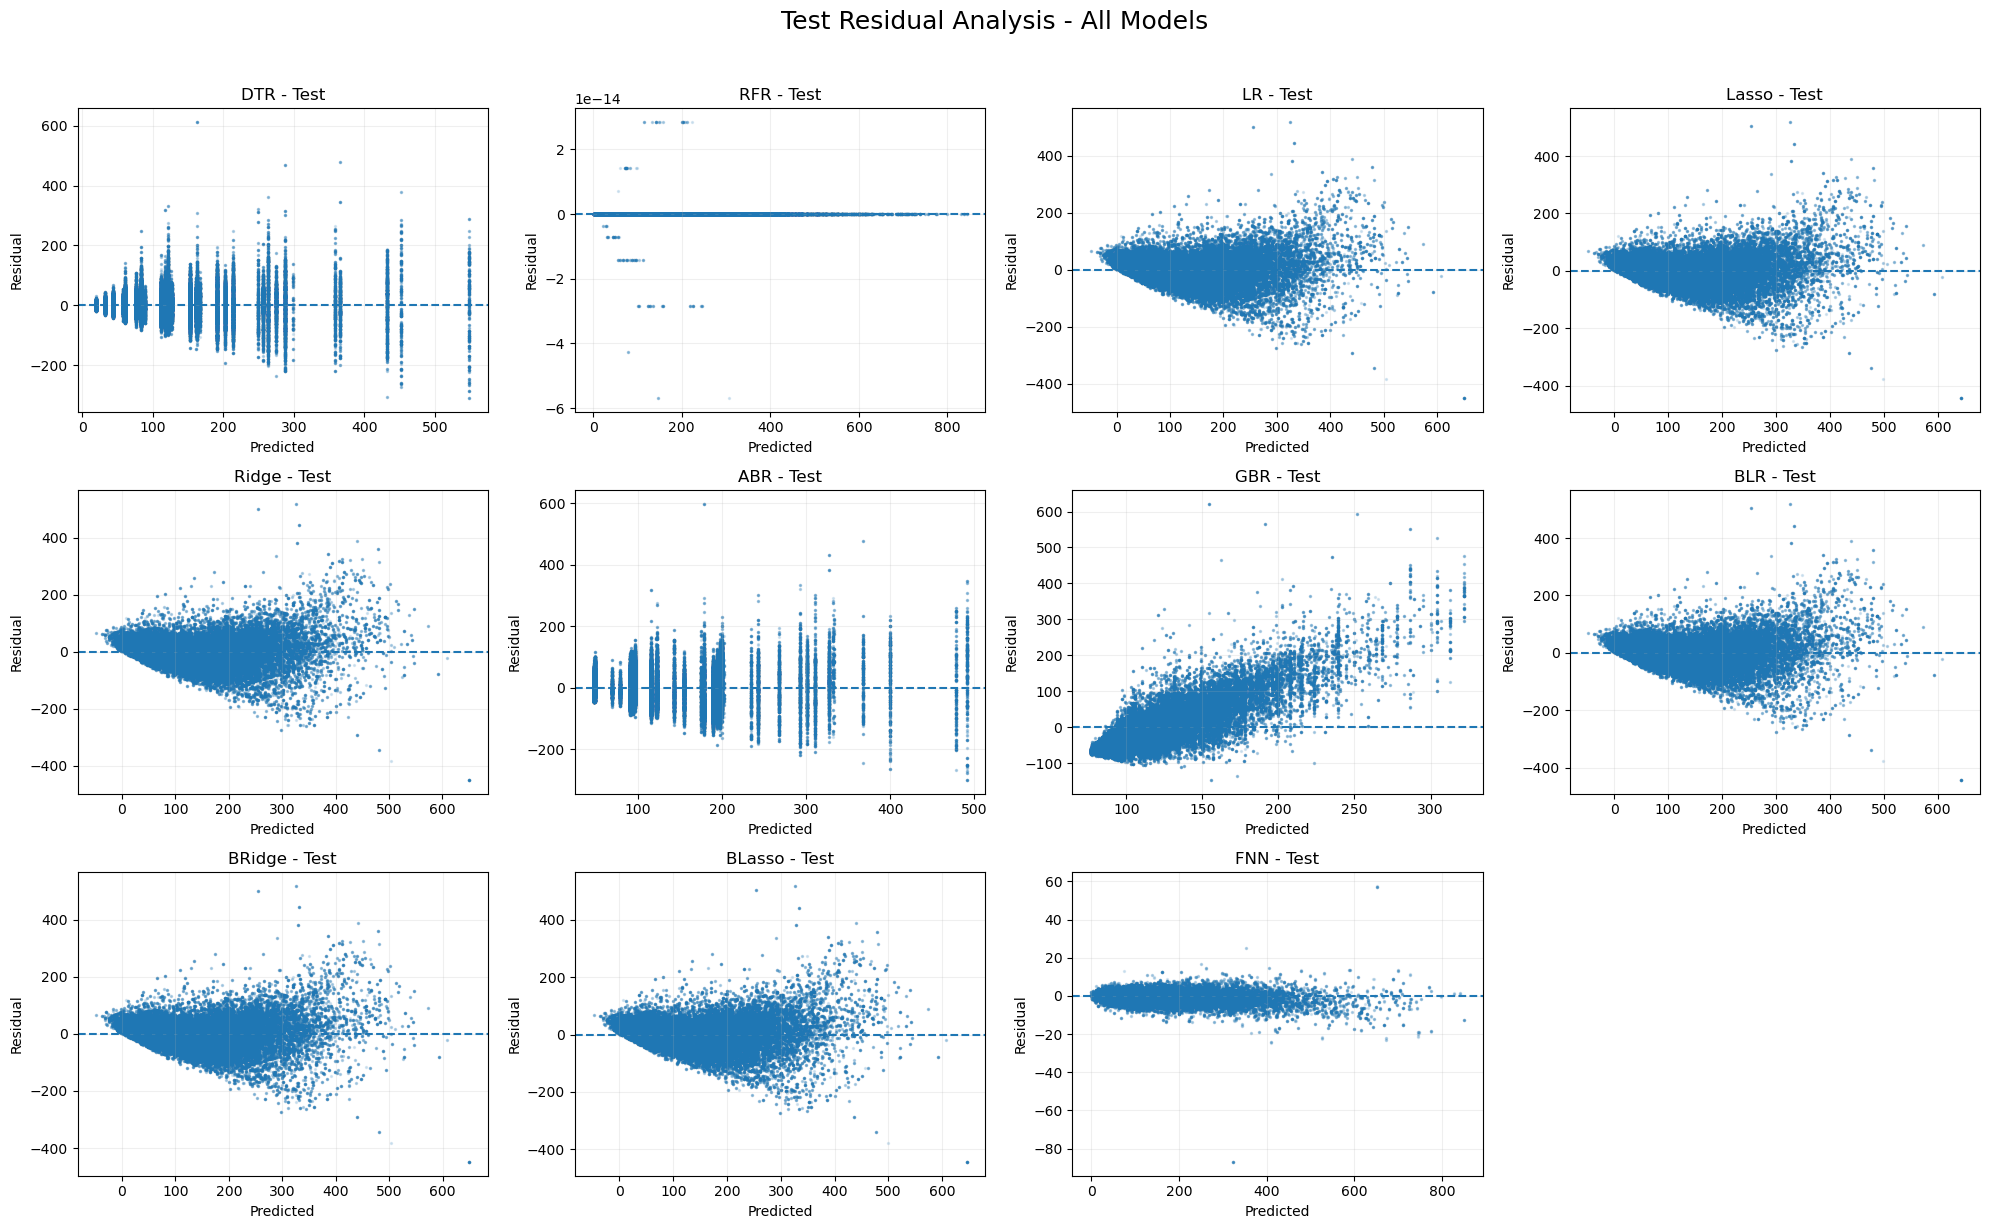

In [212]:
plot_all_test_residuals(
    models=models,
    test_loader=test_dataloader,
    xtest=xtest,
    ytest=ytest,
    device=device,
    cols=4
)

## SHAP

Background dataset has 3000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3000 when initializing the masker.



Calculating SHAP for DTR...


PermutationExplainer explainer: 3001it [00:57, 43.50it/s]                                                              
Background dataset has 3000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3000 when initializing the masker.


DTR SHAP completed.

Calculating SHAP for LR...


PermutationExplainer explainer: 3001it [00:54, 44.93it/s]                                                              
Background dataset has 3000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3000 when initializing the masker.


LR SHAP completed.

Calculating SHAP for Lasso...


PermutationExplainer explainer: 3001it [00:53, 45.05it/s]                                                              


Lasso SHAP completed.

Calculating SHAP for FNN...


PermutationExplainer explainer: 3001it [01:39, 26.83it/s]                                                              


FNN SHAP completed.

FNN - GLOBAL FEATURE IMPORTANCE
        Feature  Mean_Absolute_SHAP
   PM10 (µg/m³)           40.802306
        AT (°C)           11.531475
         RH (%)           10.860622
Benzene (µg/m³)            9.976918
     NO (µg/m³)            7.438246
     SR (W/mt2)            7.032380
    NH3 (µg/m³)            5.656277
      NOx (ppb)            5.299372
      BP (mmHg)            4.789581
  Ozone (µg/m³)            4.335855
      Timestamp            3.904539
       WD (deg)            3.901328
    NO2 (µg/m³)            3.798196
Toluene (µg/m³)            3.289357
    SO2 (µg/m³)            2.575685
     CO (mg/m³)            1.759825
       WS (m/s)            0.900160
       location            0.016782

DTR - GLOBAL FEATURE IMPORTANCE
        Feature  Mean_Absolute_SHAP
   PM10 (µg/m³)           46.200731
        AT (°C)           15.098717
Benzene (µg/m³)           10.995056
         RH (%)            5.559677
      Timestamp            5.552480
Toluene (µg/m³

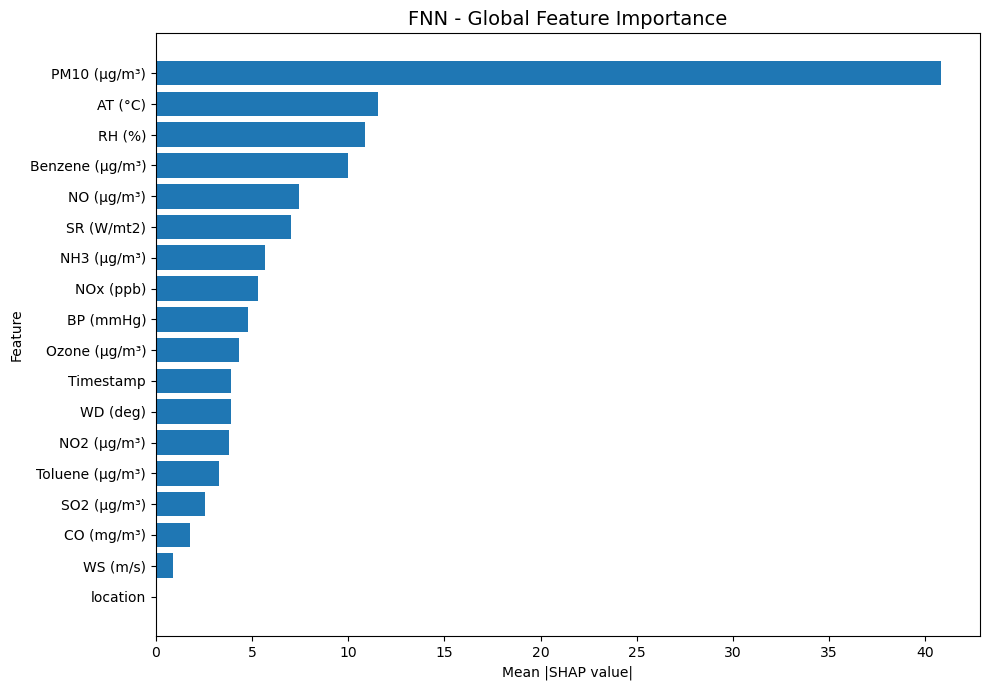

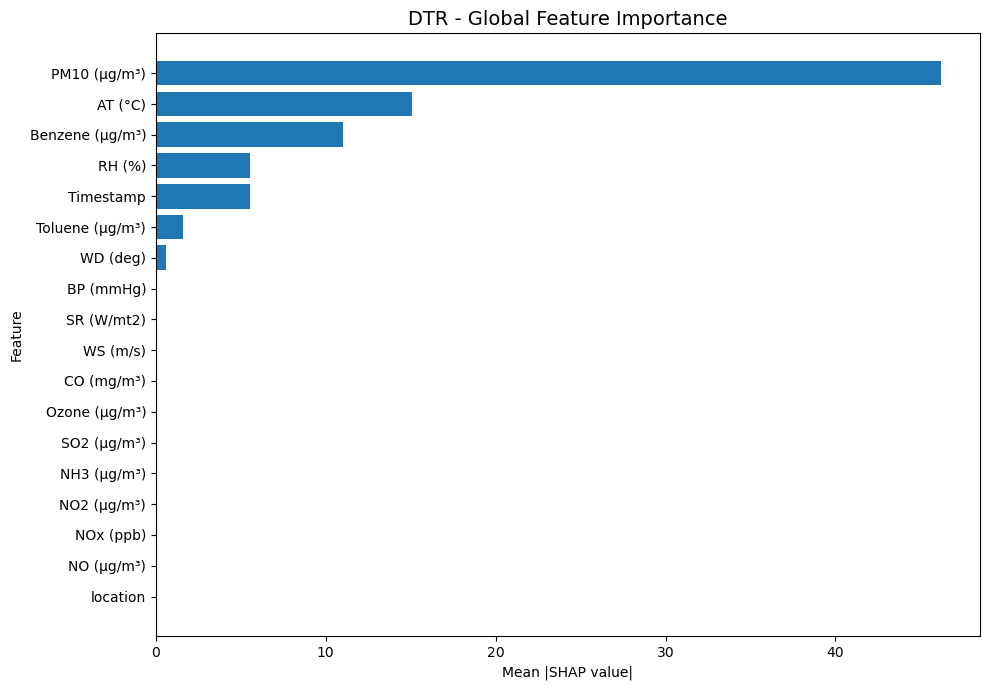

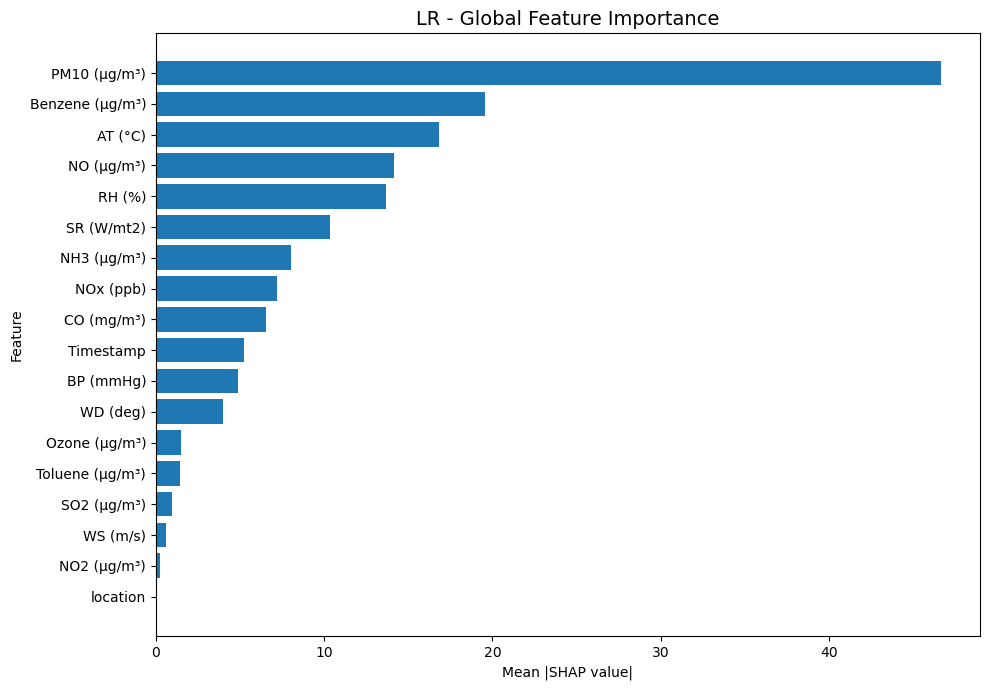

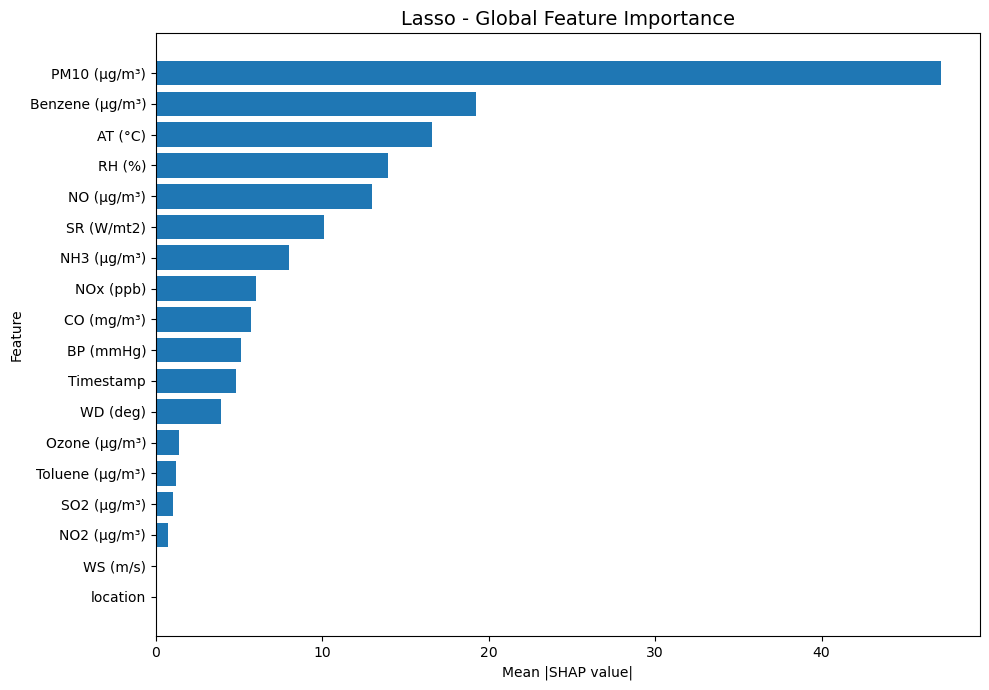


Generating beeswarm plot for FNN...


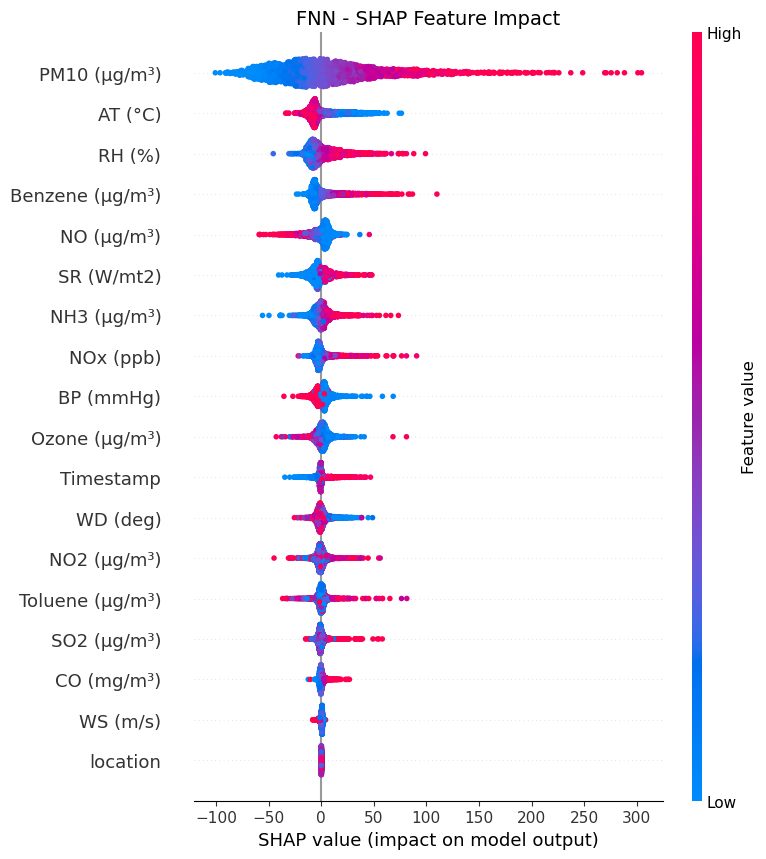


Generating beeswarm plot for DTR...


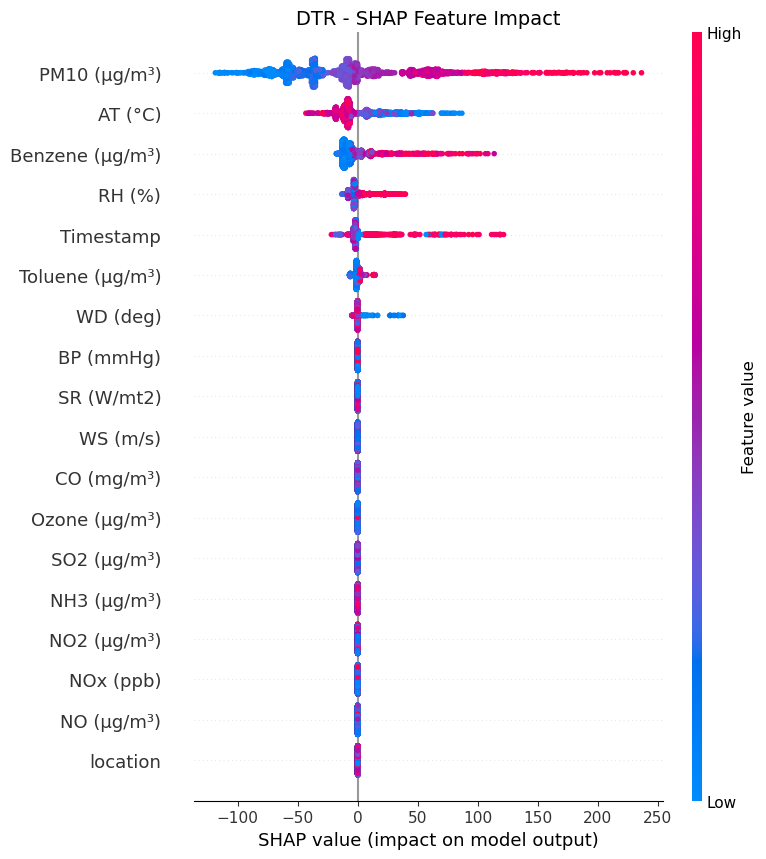


Generating beeswarm plot for LR...


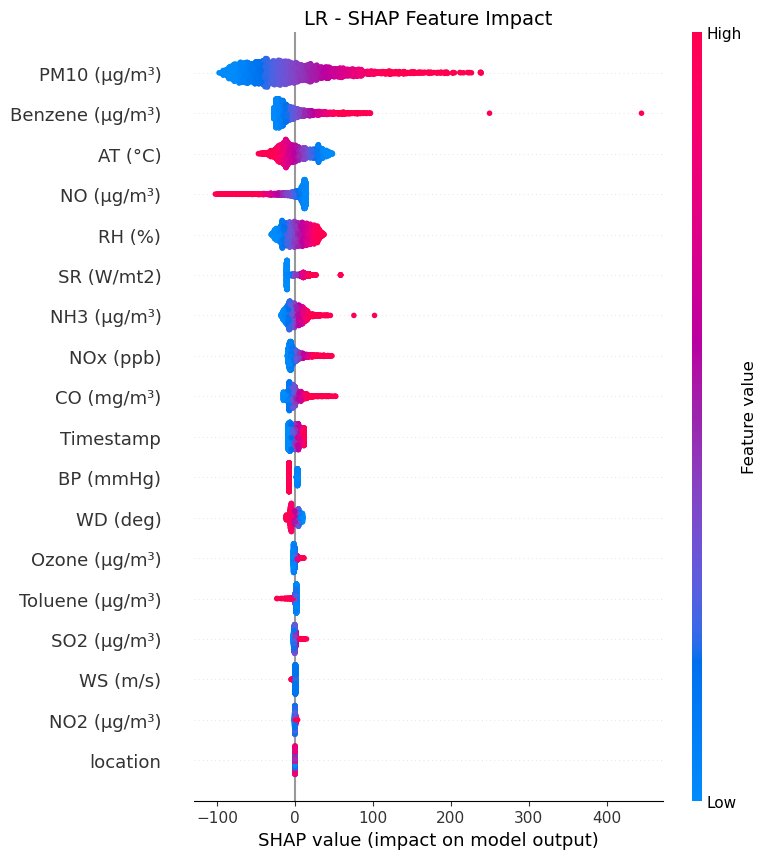


Generating beeswarm plot for Lasso...


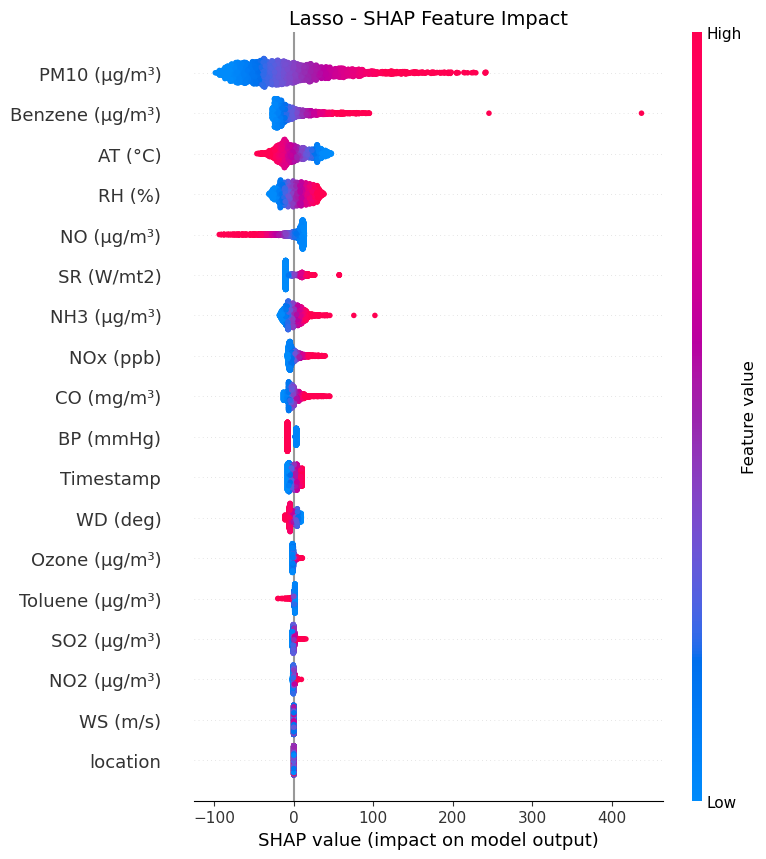

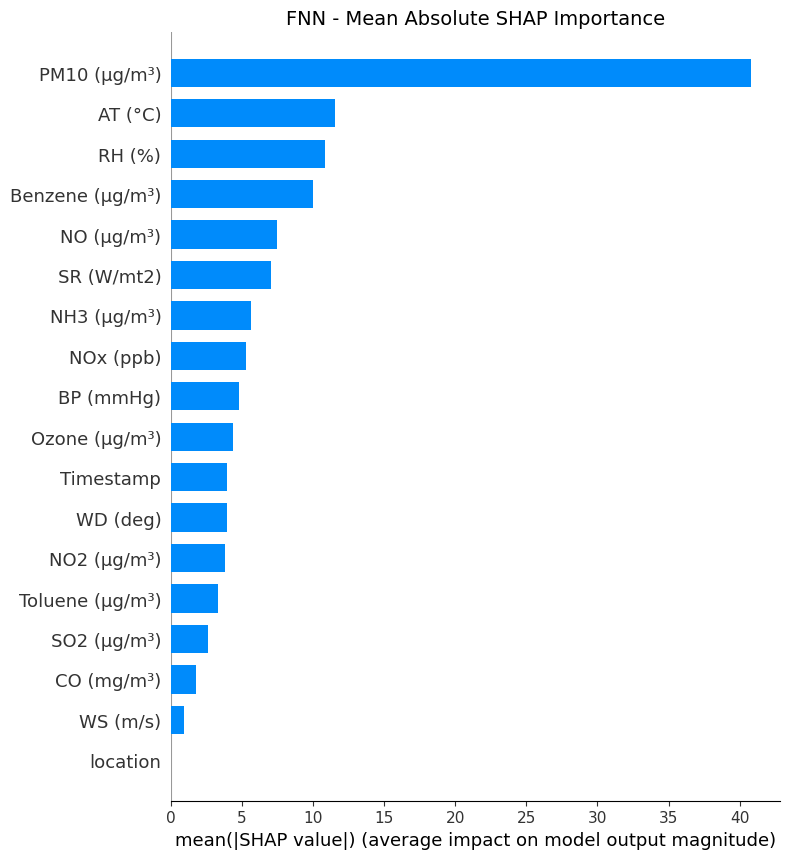

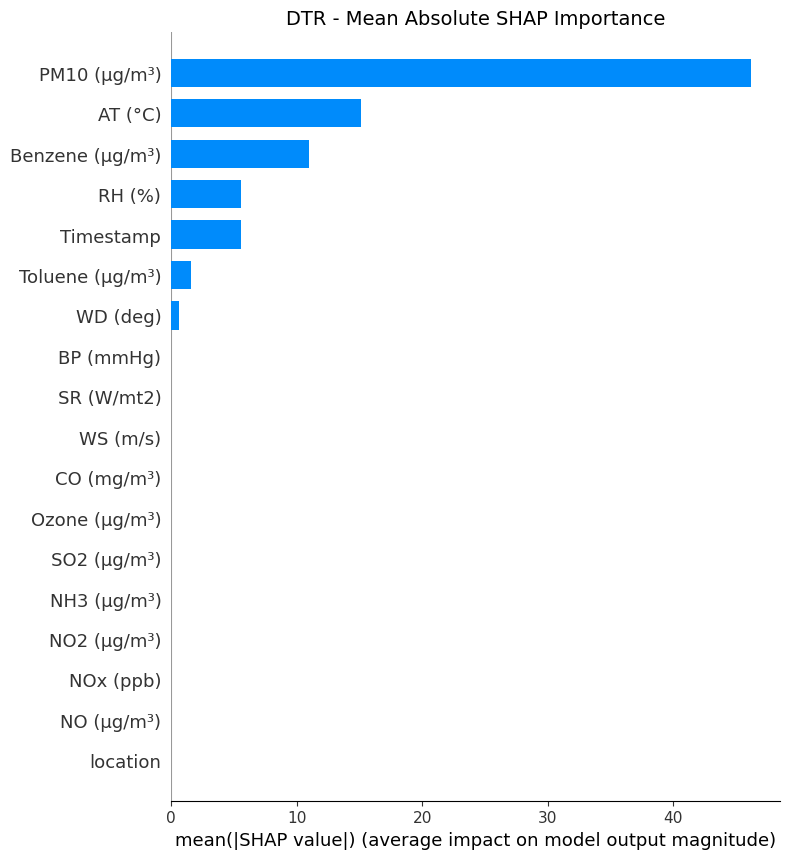

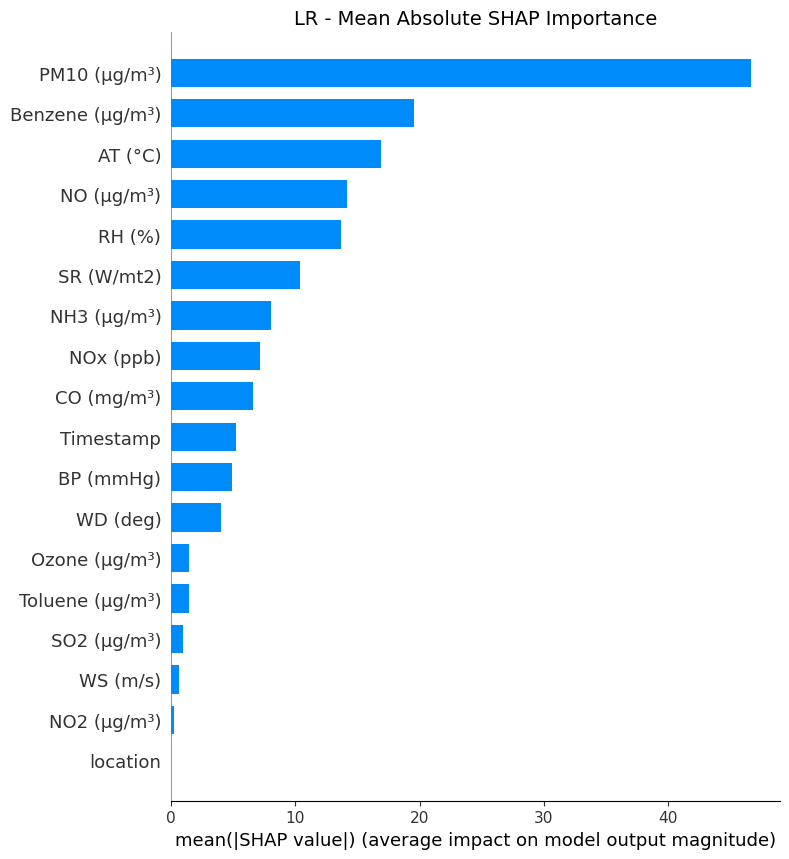

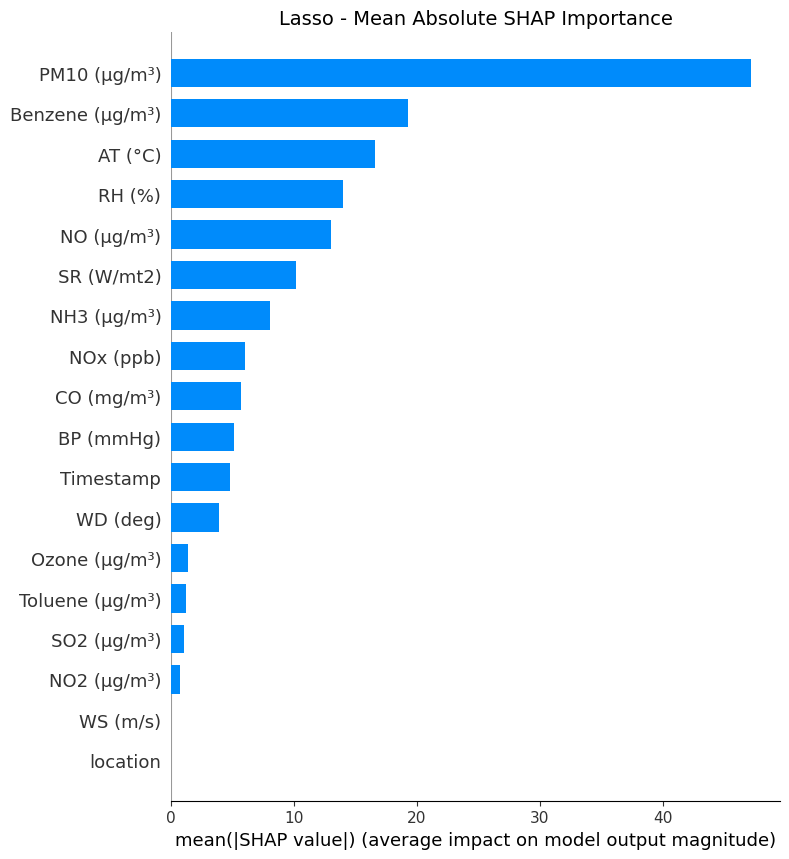


Waterfall plot: FNN


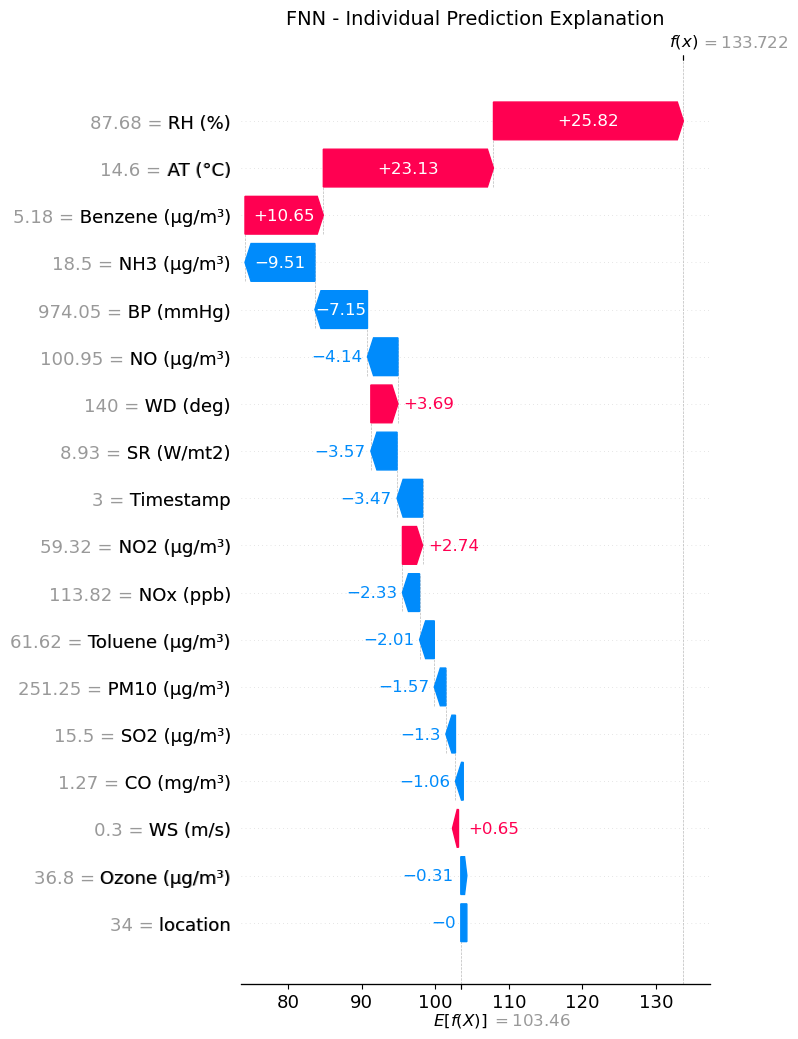


Waterfall plot: DTR


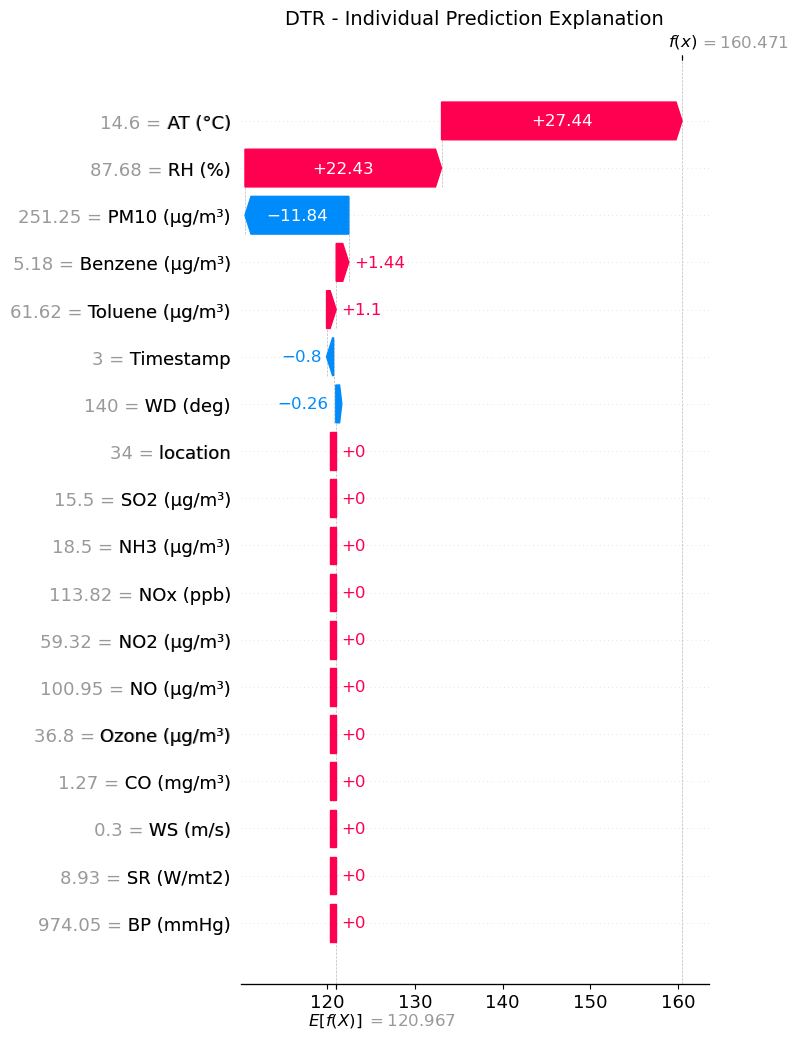


Waterfall plot: LR


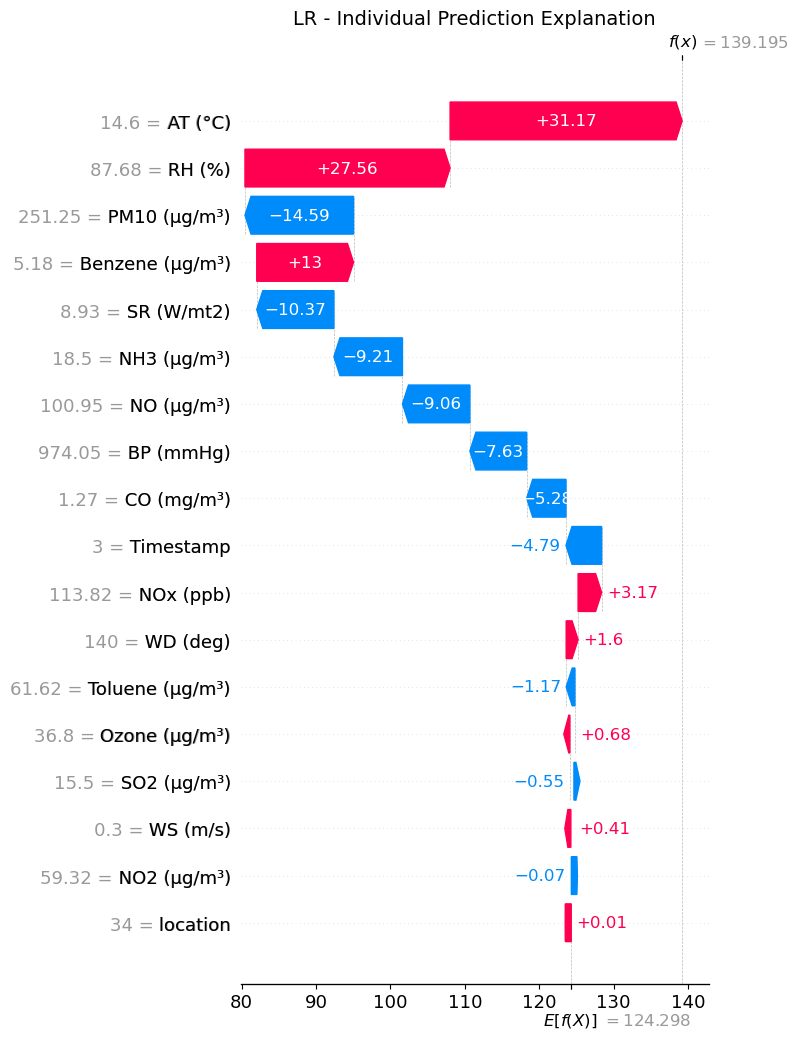


Waterfall plot: Lasso


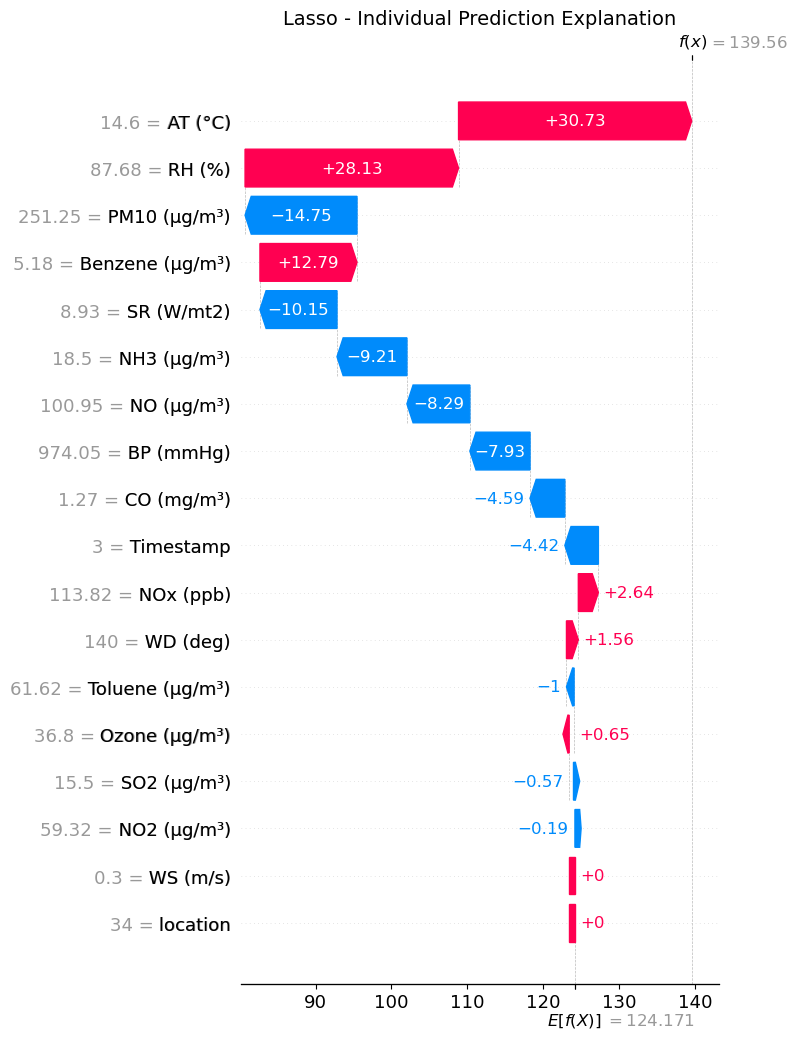



SHAP FEATURE IMPORTANCE COMPARISON
                       FNN        DTR         LR         Lasso
PM10 (µg/m³)     40.802306  46.200731  46.647565  4.716682e+01
AT (°C)          11.531475  15.098717  16.847628  1.660506e+01
RH (%)           10.860622   5.559677  13.661140  1.394314e+01
Benzene (µg/m³)   9.976918  10.995056  19.570908  1.924457e+01
NO (µg/m³)        7.438246   0.000000  14.160980  1.296805e+01
SR (W/mt2)        7.032380   0.000000  10.345699  1.013140e+01
NH3 (µg/m³)       5.656277   0.000000   8.003083  8.004504e+00
NOx (ppb)         5.299372   0.000000   7.179526  5.993552e+00
BP (mmHg)         4.789581   0.000000   4.892183  5.084534e+00
Ozone (µg/m³)     4.335855   0.000000   1.475904  1.401682e+00
Timestamp         3.904539   5.552480   5.224299  4.818275e+00
WD (deg)          3.901328   0.589882   4.007224  3.915613e+00
NO2 (µg/m³)       3.798196   0.000000   0.255747  7.428117e-01
Toluene (µg/m³)   3.289357   1.604008   1.413882  1.210605e+00
SO2 (µg/m³)       

In [217]:
# SHAP ANALYSIS
# Models:
# 1. FNN
# 2. Decision Tree Regressor
# 3. Linear Regression
# 4. Lasso

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# MODELS

models = {
    "FNN": FNN_model,
    "DTR": decitree,
    "LR": linreg,
    "Lasso": lasso
}


# CREATE FOLDER FOR SHAP IMAGES

from pathlib import Path

shap_folder = Path("SHAP_Images")
shap_folder.mkdir(exist_ok=True)


# 2. PREPARE DATA
# Convert test data to numpy
if hasattr(xtest, "values"):
    X_test = xtest.values
else:
    X_test = np.asarray(xtest)

# Feature names
if hasattr(xtest, "columns"):
    feature_names = list(xtest.columns)
else:
    feature_names = [f"Feature_{i+1}" for i in range(X_test.shape[1])]

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)


# 3. USE A SMALL REPRESENTATIVE TEST SAMPLE
# Your dataset is very large, so SHAP should NOT be calculated
# over the entire test set.

np.random.seed(33)

shap_sample_size = min(3000, len(X_test))

sample_idx = np.random.choice(
    len(X_test),
    shap_sample_size,
    replace=False
)

X_shap = X_test_df.iloc[sample_idx].copy()


# 4. SHAP RESULTS STORAGE

shap_values_dict = {}
explainer_dict = {}


# 5. SKLEARN MODELS

for name in ["DTR", "LR", "Lasso"]:

    model = models[name]

    print(f"\nCalculating SHAP for {name}...")

    explainer = shap.Explainer(
        model.predict,
        X_shap
    )

    shap_result = explainer(X_shap)

    explainer_dict[name] = explainer
    shap_values_dict[name] = shap_result

    print(f"{name} SHAP completed.")


# 6. FNN / PYTORCH MODEL

print("\nCalculating SHAP for FNN...")

FNN_model.eval()


# Detect device

try:
    fnn_device = next(FNN_model.parameters()).device
except StopIteration:
    fnn_device = device


# Prediction function for SHAP

def fnn_predict(X):

    X = np.asarray(X, dtype=np.float32)

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=fnn_device
    )

    with torch.no_grad():
        output = FNN_model(X_tensor)

    output = output.squeeze(-1)

    return output.detach().cpu().numpy()


# Background data

background_size = min(100, len(X_shap))

background_idx = np.random.choice(
    len(X_shap),
    background_size,
    replace=False
)

X_background = X_shap.iloc[background_idx]


# SHAP Explainer

fnn_explainer = shap.Explainer(
    fnn_predict,
    X_background
)

fnn_shap = fnn_explainer(X_shap)

explainer_dict["FNN"] = fnn_explainer
shap_values_dict["FNN"] = fnn_shap

print("FNN SHAP completed.")


# 7. GLOBAL FEATURE IMPORTANCE

for name in models.keys():

    print(f"\n{'='*60}")
    print(f"{name} - GLOBAL FEATURE IMPORTANCE")
    print(f"{'='*60}")

    shap_result = shap_values_dict[name]

    shap_values = np.asarray(shap_result.values)

    # For single-output regression
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean_Absolute_SHAP": mean_abs_shap
    })

    importance_df = importance_df.sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )

    print(importance_df.to_string(index=False))


# 8. GLOBAL BAR PLOTS

for name in models.keys():

    plt.figure(figsize=(10, 7))

    shap_values = np.asarray(
        shap_values_dict[name].values
    )

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": mean_abs_shap
    }).sort_values(
        "Importance",
        ascending=True
    )

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Feature")
    plt.title(
        f"{name} - Global Feature Importance",
        fontsize=14
    )

    plt.tight_layout()

    plt.savefig(
        shap_folder / f"{name}_Global_Feature_Importance.png",
        dpi=1000,
        format="png",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# 9. SHAP BEESWARM PLOTS

for name in models.keys():

    print(f"\nGenerating beeswarm plot for {name}...")

    plt.figure(figsize=(11, 7))

    shap_result = shap_values_dict[name]

    shap_values = np.asarray(shap_result.values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    shap.summary_plot(
        shap_values,
        X_shap,
        feature_names=feature_names,
        show=False
    )

    plt.title(
        f"{name} - SHAP Feature Impact",
        fontsize=14
    )

    plt.tight_layout()

    plt.savefig(
        shap_folder / f"{name}_SHAP_Beeswarm.png",
        dpi=1000,
        format="png",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# 10. SHAP BAR SUMMARY PLOTS

for name in models.keys():

    plt.figure(figsize=(10, 7))

    shap_result = shap_values_dict[name]

    shap_values = np.asarray(shap_result.values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    shap.summary_plot(
        shap_values,
        X_shap,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )

    plt.title(
        f"{name} - Mean Absolute SHAP Importance",
        fontsize=14
    )

    plt.tight_layout()

    plt.savefig(
        shap_folder / f"{name}_SHAP_Bar_Summary.png",
        dpi=1000,
        format="png",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# 11. WATERFALL PLOT FOR ONE SAMPLE

sample_number = 0

for name in models.keys():

    print(f"\nWaterfall plot: {name}")

    shap_result = shap_values_dict[name]

    plt.figure(figsize=(10, 7))

    shap.plots.waterfall(
        shap_result[sample_number],
        max_display=18,
        show=False
    )

    plt.title(
        f"{name} - Individual Prediction Explanation",
        fontsize=14
    )

    plt.tight_layout()

    plt.savefig(
        shap_folder / f"{name}_Individual_Prediction_Waterfall.png",
        dpi=1000,
        format="png",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# 12. FEATURE IMPORTANCE COMPARISON

importance_comparison = pd.DataFrame(
    index=feature_names
)

for name in models.keys():

    shap_values = np.asarray(
        shap_values_dict[name].values
    )

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    importance_comparison[name] = (
        np.abs(shap_values).mean(axis=0)
    )


importance_comparison = importance_comparison.sort_values(
    by="FNN",
    ascending=False
)


print("\n")
print("=" * 80)
print("SHAP FEATURE IMPORTANCE COMPARISON")
print("=" * 80)

print(
    importance_comparison.to_string()
)


# 13. NORMALIZED FEATURE IMPORTANCE

normalized_importance = (
    importance_comparison /
    importance_comparison.sum(axis=0)
)

print("\n")
print("=" * 80)
print("NORMALIZED SHAP IMPORTANCE")
print("=" * 80)

print(
    normalized_importance.to_string()
)


# 14. TOP FEATURES ACROSS ALL MODELS

top_features = {}

for name in models.keys():

    top_features[name] = (
        importance_comparison[name]
        .sort_values(ascending=False)
        .head(10)
    )

print("\n")
print("=" * 80)
print("TOP 10 FEATURES FOR EACH MODEL")
print("=" * 80)

for name, values in top_features.items():

    print(f"\n{name}")

    for feature, value in values.items():
        print(f"{feature:<30} {value:.6f}")

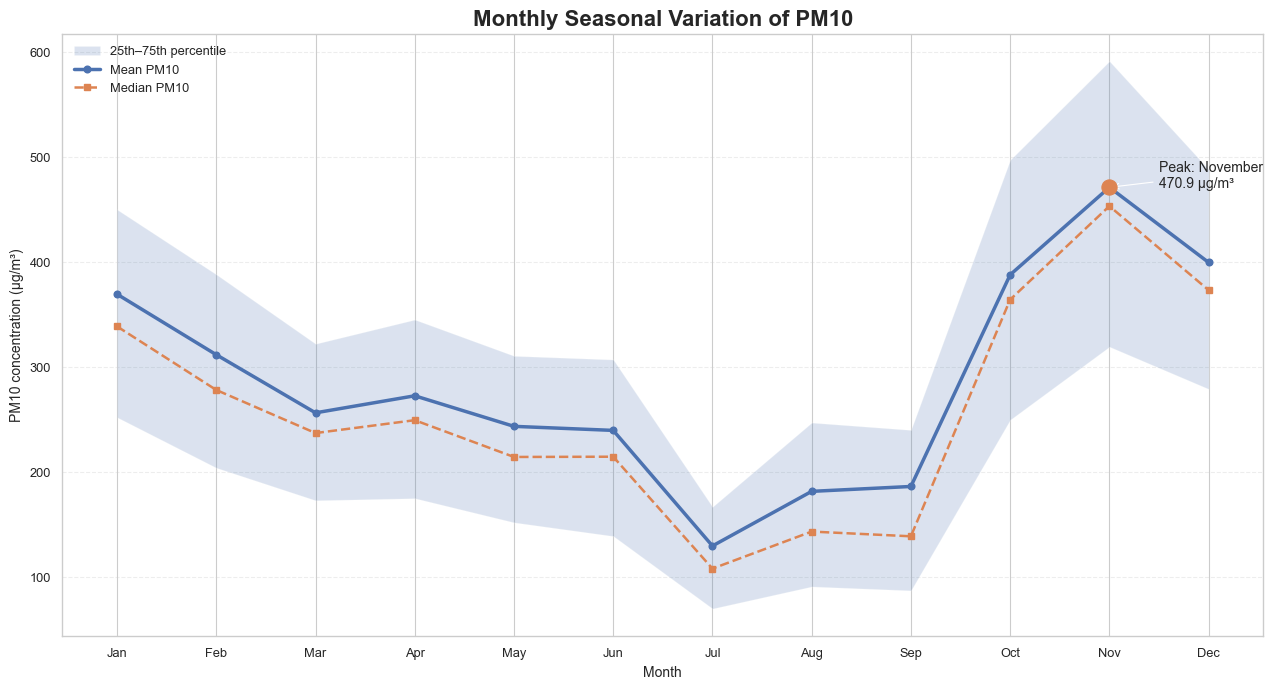

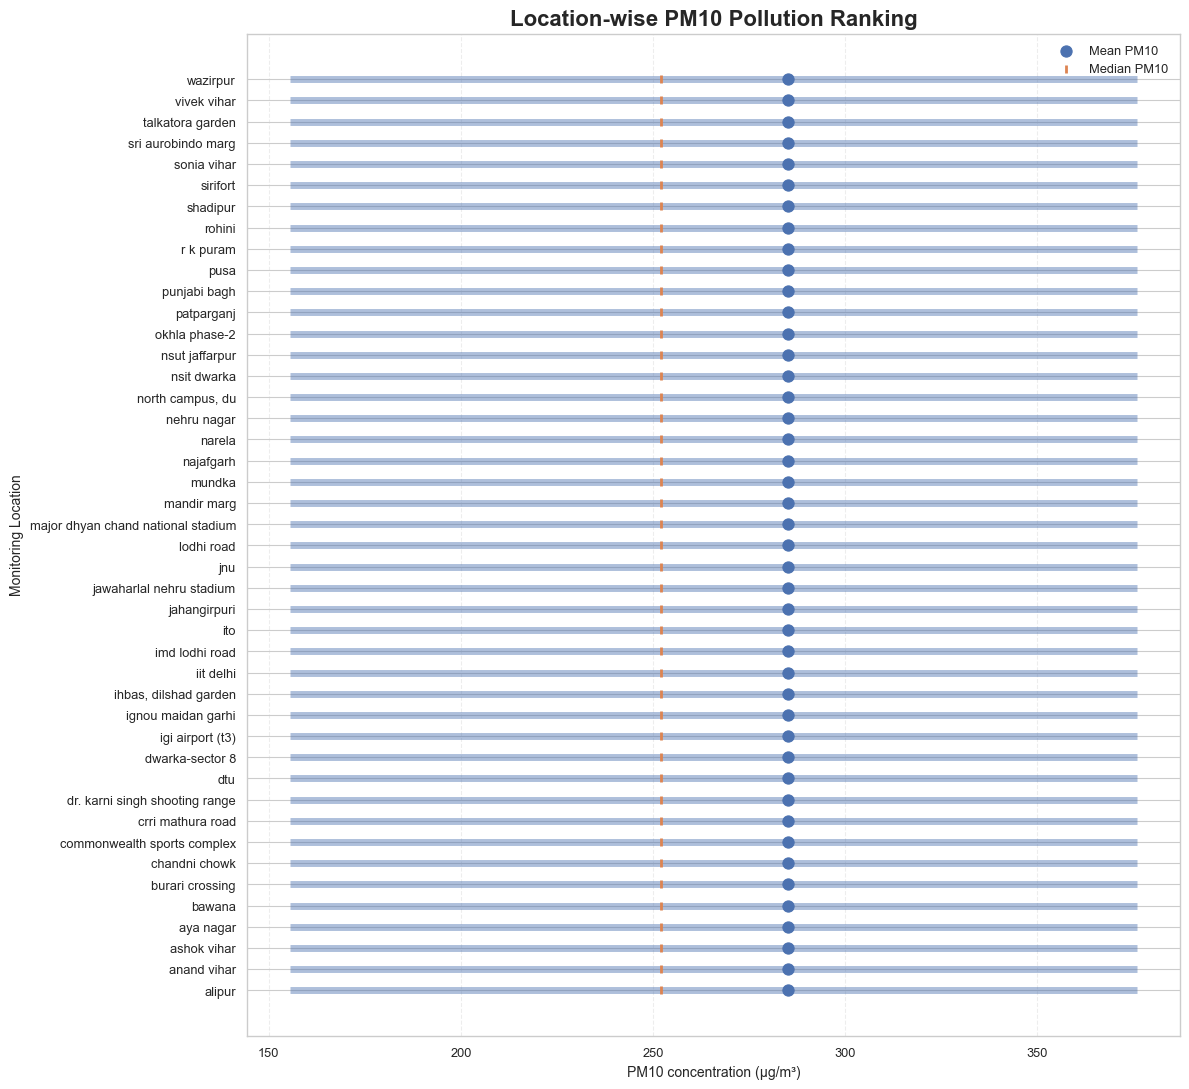

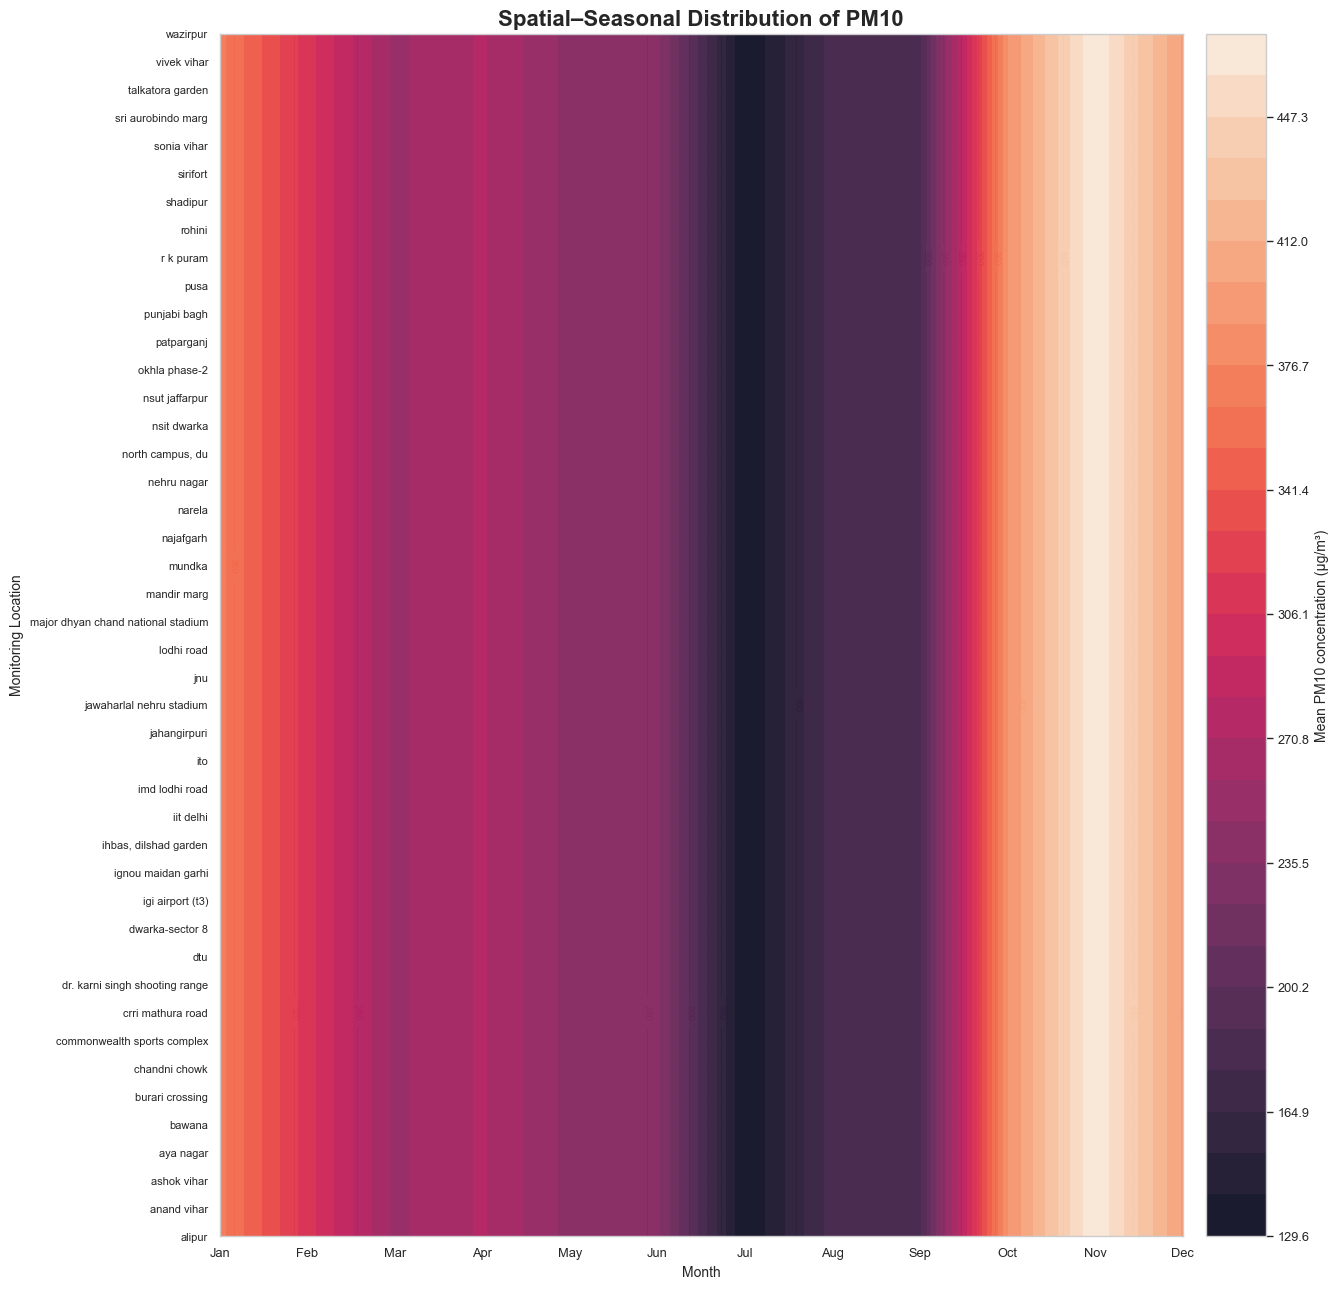


Saved:
Pollution_Visualizations\Monthly_PM10_Seasonal_Pattern.png
Pollution_Visualizations\Location_Wise_PM10_Pollution_Ranking.png
Pollution_Visualizations\PM10_Spatial_Seasonal_Distribution.png

Highest pollution location:
alipur → 284.99 µg/m³

Highest pollution month:
November → 470.87 µg/m³


In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path("Pollution_Visualizations")
SAVE_DIR.mkdir(exist_ok=True)

df = final_df.copy()

pollutant = "PM10 (µg/m³)"

# Location names
codes = sorted(df["location"].dropna().unique())

try:
    names = le.inverse_transform(np.array(codes, dtype=int))
    location_map = dict(zip(codes, names))
    df["Location_Name"] = df["location"].map(location_map)
except:
    df["Location_Name"] = df["location"].astype(str)

# Month
df["Month"] = pd.to_numeric(df["Timestamp"], errors="coerce")
df[pollutant] = pd.to_numeric(df[pollutant], errors="coerce")

df = df[
    df["Month"].between(1, 12)
    & df[pollutant].notna()
    & df["Location_Name"].notna()
].copy()

months = {
    1:"January", 2:"February", 3:"March", 4:"April",
    5:"May", 6:"June", 7:"July", 8:"August",
    9:"September", 10:"October", 11:"November", 12:"December"
}


# ============================================================
# 1. MONTHLY PM10
# ============================================================

monthly = (
    df.groupby("Month")[pollutant]
    .agg(
        Mean="mean",
        Median="median",
        Q25=lambda x: x.quantile(.25),
        Q75=lambda x: x.quantile(.75)
    )
    .reindex(range(1, 13))
)

x = np.arange(1, 13)

fig, ax = plt.subplots(figsize=(13, 7))

ax.fill_between(
    x,
    monthly["Q25"],
    monthly["Q75"],
    alpha=.20,
    label="25th–75th percentile"
)

ax.plot(
    x,
    monthly["Mean"],
    marker="o",
    linewidth=2.5,
    label="Mean PM10"
)

ax.plot(
    x,
    monthly["Median"],
    marker="s",
    linestyle="--",
    linewidth=1.8,
    label="Median PM10"
)

peak_month = monthly["Mean"].idxmax()
peak_value = monthly.loc[peak_month, "Mean"]

ax.scatter(peak_month, peak_value, s=120, zorder=5)

ax.annotate(
    f"Peak: {months[peak_month]}\n{peak_value:.1f} µg/m³",
    xy=(peak_month, peak_value),
    xytext=(peak_month + .5, peak_value),
    arrowprops=dict(arrowstyle="->")
)

ax.set_xticks(x)
ax.set_xticklabels([months[i][:3] for i in x])
ax.set_xlabel("Month")
ax.set_ylabel("PM10 concentration (µg/m³)")
ax.set_title(
    "Monthly Seasonal Variation of PM10",
    fontsize=16,
    fontweight="bold"
)
ax.grid(axis="y", linestyle="--", alpha=.35)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    SAVE_DIR / "Monthly_PM10_Seasonal_Pattern.png",
    dpi=1000,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ============================================================
# 2. LOCATION-WISE PM10
# ============================================================

location_stats = (
    df.groupby("Location_Name")[pollutant]
    .agg(
        Mean="mean",
        Median="median",
        Q25=lambda x: x.quantile(.25),
        Q75=lambda x: x.quantile(.75)
    )
    .sort_values("Mean", ascending=False)
)

plot_data = location_stats.sort_values("Mean")

y = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(12, 11))

ax.hlines(
    y,
    plot_data["Q25"],
    plot_data["Q75"],
    linewidth=5,
    alpha=.45
)

ax.scatter(
    plot_data["Mean"],
    y,
    s=65,
    zorder=3,
    label="Mean PM10"
)

ax.scatter(
    plot_data["Median"],
    y,
    s=40,
    marker="|",
    linewidth=2,
    zorder=4,
    label="Median PM10"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_data.index)
ax.set_xlabel("PM10 concentration (µg/m³)")
ax.set_ylabel("Monitoring Location")
ax.set_title(
    "Location-wise PM10 Pollution Ranking",
    fontsize=16,
    fontweight="bold"
)
ax.grid(axis="x", linestyle="--", alpha=.35)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    SAVE_DIR / "Location_Wise_PM10_Pollution_Ranking.png",
    dpi=1000,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ============================================================
# 3. LOCATION × MONTH SMOOTH CONTOUR
# ============================================================

matrix = (
    df.groupby(["Location_Name", "Month"])[pollutant]
    .mean()
    .unstack()
    .reindex(columns=range(1, 13))
)

matrix = matrix.reindex(
    location_stats.index
)

matrix = matrix.interpolate(
    axis=1,
    limit_direction="both"
)

matrix = matrix.interpolate(
    axis=0,
    limit_direction="both"
)

Z = matrix.to_numpy()

X, Y = np.meshgrid(
    np.arange(1, 13),
    np.arange(len(matrix))
)

fig, ax = plt.subplots(figsize=(14, 13))

levels = np.linspace(
    np.nanmin(Z),
    np.nanmax(Z),
    30
)

filled = ax.contourf(
    X,
    Y,
    Z,
    levels=levels,
    alpha=.92
)

lines = ax.contour(
    X,
    Y,
    Z,
    levels=8,
    linewidths=.6,
    alpha=.45
)

ax.clabel(
    lines,
    inline=True,
    fontsize=7,
    fmt="%.0f"
)

cbar = fig.colorbar(
    filled,
    ax=ax,
    pad=.02
)

cbar.set_label(
    "Mean PM10 concentration (µg/m³)"
)

ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(
    [months[i][:3] for i in range(1, 13)]
)

ax.set_yticks(np.arange(len(matrix)))
ax.set_yticklabels(
    matrix.index,
    fontsize=8
)

ax.set_xlabel("Month")
ax.set_ylabel("Monitoring Location")

ax.set_title(
    "Spatial–Seasonal Distribution of PM10",
    fontsize=16,
    fontweight="bold"
)

ax.grid(alpha=.15, linestyle="--")

plt.tight_layout()
plt.savefig(
    SAVE_DIR / "PM10_Spatial_Seasonal_Distribution.png",
    dpi=1000,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ============================================================
# RESULTS
# ============================================================

print("\nSaved:")
print(SAVE_DIR / "Monthly_PM10_Seasonal_Pattern.png")
print(SAVE_DIR / "Location_Wise_PM10_Pollution_Ranking.png")
print(SAVE_DIR / "PM10_Spatial_Seasonal_Distribution.png")

print("\nHighest pollution location:")
print(
    location_stats.index[0],
    f"→ {location_stats.iloc[0]['Mean']:.2f} µg/m³"
)

print("\nHighest pollution month:")
print(
    months[peak_month],
    f"→ {peak_value:.2f} µg/m³"
)